<a href="https://colab.research.google.com/github/Hanniix22/BSC_DPDM2025/blob/main/LinearSVR_V23_11_TMD_ALLcluster_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%pip install torch_geometric

## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [6]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [7]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Hyperparameters

In [8]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =7 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [9]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [12]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [13]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [14]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [15]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [16]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [17]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [18]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [19]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [20]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [21]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

## Summarises all climate index

In [22]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [23]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [24]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [25]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [26]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [27]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


# Feature selection part

## Focus only feature of climate

In [28]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [29]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [30]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [31]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


In [32]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [33]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

In [34]:
fold[0][0]

[            RMM_AMPLITUDE    BSISO1       DMI       SWM        NE  \
 DATE                                                                
 1982-01-01       0.714459 -0.948166 -0.023677  1.469381  1.793781   
 1982-02-01       0.281839 -0.948166  1.265857  0.837625  1.758152   
 1982-03-01       0.443087 -0.948166  0.981589  0.424145  1.158306   
 1982-04-01       0.738476 -0.948166  1.140032  0.264021  1.416414   
 1982-05-01      -0.930963  0.774939  1.531242 -0.468001  0.380173   
 ...                   ...       ...       ...       ...       ...   
 2019-08-01      -0.930963  1.268179  2.643234 -0.995432 -1.033522   
 2019-09-01      -0.930963  0.932615  3.007009 -1.467186 -1.029036   
 2019-10-01      -0.930963  0.717530  4.054789 -1.652670 -0.257663   
 2019-11-01       1.058389 -0.948166  3.547012 -0.585071  0.857334   
 2019-12-01       0.323061 -0.948166  1.588506  0.643445  1.242208   
 
                Month_sin     Month_cos    300201  
 DATE                               

เลือก feature ตาม index ที่กำหนด

แบ่งข้อมูลเป็น Fold และเลือก Feature ที่ต้องการจากแต่ละชุดข้อมูล

fold

 ├── Fold1
 │     ├── Test
 │     ├── Train
 │     └── Validation


 └── Fold2
       ├── Test
       ├── Train
       └── Validation


       ทุก dataset
        ↓
        ถูกเลือกเฉพาะ feature ตาม index
        ↓
        เหลือเฉพาะ feature ที่ต้องใช้ train model

In [35]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [36]:
cluster_station= []
for index in range(0,len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [37]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

300201
300202
303201
303301
327501
328201
331201
331301
331401


In [38]:
fold[0][0][5]

,RMM_AMPLITUDE,BSISO1,DMI,SWM,NE,Month_sin,Month_cos,327202
DATE,,,,,,,,
1982-01-01,0.714459,-0.948166,-0.023677,1.469381,1.793781,5.000000e-01,8.660254e-01,-1.027339
1982-02-01,0.281839,-0.948166,1.265857,0.837625,1.758152,8.660254e-01,5.000000e-01,-1.127137
1982-03-01,0.443087,-0.948166,0.981589,0.424145,1.158306,1.000000e+00,6.123234e-17,-0.994672
1982-04-01,0.738476,-0.948166,1.140032,0.264021,1.416414,8.660254e-01,-5.000000e-01,-0.501068
1982-05-01,-0.930963,0.774939,1.531242,-0.468001,0.380173,5.000000e-01,-8.660254e-01,0.500499
...,...,...,...,...,...,...,...,...
2019-08-01,-0.930963,1.268179,2.643234,-0.995432,-1.033522,-8.660254e-01,-5.000000e-01,1.872538
2019-09-01,-0.930963,0.932615,3.007009,-1.467186,-1.029036,-1.000000e+00,-1.836970e-16,0.081923
2019-10-01,-0.930963,0.717530,4.054789,-1.652670,-0.257663,-8.660254e-01,5.000000e-01,-0.553480


Create node

Creat training test set for each station

Create static features

In [39]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [40]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [41]:
climate_name_list

['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']

Add snapshot signal in = Windows , out = 12

Train_df_listCreate edges

In [42]:
num_feature

7

Convert to homogenious structure

In [43]:


# Station id
s=0



#Sliding window Train
fold_tensor = copy.deepcopy(fold)

for fold_index in range(k_fold_num):
    train_set =[]
    train= HeteroData()

    test_set =[]
    test= HeteroData()

    val_set =[]
    val = HeteroData()


    for j in range(len(fold[fold_index][0][s]) - window_size - horizon + 1):
        # if j%(window_size-1)==0: #
        #if j%3==0: #
        tan_x=[]
        rain_fall_x=[]
        rain_fall_y=[]

        for station in cluster_station:
            tan_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            train[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][0]), dtype=torch.float32)
        train['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        train['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)

        train_set.append(copy.deepcopy(train))

    fold_tensor[fold_index][0] = train_set
    #Sliding window Test

    for j in range(len(fold[fold_index][1][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            test[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][1]), dtype=torch.float32)


        test['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        test['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)


        test_set.append(copy.deepcopy(test))

    fold_tensor[fold_index][1] = test_set


    for j in range(len(fold[fold_index][2][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j+window_size:j+window_size+horizon])])

        for climate_index in range(len(climate_name_list)):
            val[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][2]), dtype=torch.float32)

        val['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        val['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)



        val_set.append(copy.deepcopy(val))

    fold_tensor[fold_index][2] = val_set



In [44]:
train_set.append(copy.deepcopy(train))

In [45]:
train_set

[HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   Month_cos={ x=[9, 1, 24] },
   station={
     x=[9, 1, 24],
     y=[9, 1, 12],
   }
 ),
 HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   Month_cos={ x=[9, 1, 24] },
   station={
     x=[9, 1, 24],
     y=[9, 1, 12],
   }
 ),
 HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   Month_cos={ x=[9, 1, 24] },
   station={
     x=[9, 1, 24],
     y=[9, 1, 12],
   }
 ),
 HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   

In [46]:
test_set

[HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   Month_cos={ x=[9, 1, 24] },
   station={
     x=[9, 1, 24],
     y=[9, 1, 12],
   }
 )]

In [47]:
val_set

[HeteroData(
   RMM_AMPLITUDE={ x=[9, 1, 24] },
   BSISO1={ x=[9, 1, 24] },
   DMI={ x=[9, 1, 24] },
   SWM={ x=[9, 1, 24] },
   NE={ x=[9, 1, 24] },
   Month_sin={ x=[9, 1, 24] },
   Month_cos={ x=[9, 1, 24] },
   station={
     x=[9, 1, 24],
     y=[9, 1, 12],
   }
 )]

In [48]:
def extract_x(data):
    datax =[]
    i=0
    cluster_i=0
    for feature_index in range((num_feature)):

        datax.append([data.x[i][0].detach().cpu().numpy()])
        i=i+len(cluster_station)
    #result = torch.cat(datax, dim=1)
    for cluster_index in range(len(cluster_station)):

        datax.append([data.x[i+cluster_i][0].detach().cpu().numpy()])
        cluster_i=cluster_i+1
    return datax


In [49]:

def accuracy2D_classic(y_pred, y_target):
    y_pred=y_pred.detach().cpu().numpy()
    y_target=y_target.detach().cpu().numpy()
    y_pred =np.reshape(y_pred,y_pred.shape[0]*y_pred.shape[1])
    y_target =np.reshape(y_target,y_target.shape[0]*y_target.shape[1])
    a = [1-min(1,abs((j-i)/i)) for j,i in zip(y_pred, y_target) if i !=0]
    for i in range(len(y_target)):
        if y_target[i]==0:
            a[i] = 1-min(1,2*abs(y_pred[i]-y_target[i])/abs(y_pred[i]+y_target[i]))

    return np.array(a)

In [50]:
def transformback_future(pred,station,n):

    preds_temp = np.ones(Y_normalize_data.shape)
    for i in range(len(pred)):
        preds_temp[Y_normalize_data.shape[0]-n+i,station] =pred[pred.shape[0]-n+i]
    preds_values = scaler_Y.inverse_transform(preds_temp)
    preds_value = preds_values[preds_values.shape[0]-n:preds_values.shape[0],station]
    return (preds_value)

In [51]:
import torch
from typing import Dict, Union, List

def nse_per_station(observations, predictions, station_indices=None):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) for each station separately.

    Args:
        observations (torch.Tensor): Ground truth values, shape (num_stations, num_timesteps).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.
        station_indices (Dict[str, int], optional): Dictionary mapping station names to their
                                                  indices in the tensors.

    Returns:
        Dict[str, float]: Nash-Sutcliffe Efficiency (NSE) score for each station.
    """
    # Ensure inputs have the correct shape
    if observations.dim() != 2 or predictions.dim() != 2:
        raise ValueError("Inputs must be 2D tensors with shape (num_stations, num_timesteps)")

    if observations.shape != predictions.shape:
        raise ValueError(f"Shape mismatch: observations {observations.shape}, predictions {predictions.shape}")

    num_stations = observations.shape[0]

    # Initialize results dictionary
    if station_indices is None:
        # If no station names provided, use numerical indices
        station_indices = {str(i): i for i in range(num_stations)}

    nse_scores = {}

    # Calculate NSE for each station
    for station_name, idx in station_indices.items():
        # Get data for this station
        station_obs = observations[idx]
        station_pred = predictions[idx]

        # Skip stations with NaN values if needed
        if torch.isnan(station_obs).any() or torch.isnan(station_pred).any():
            # Handle NaN values by filtering them out
            valid_mask = ~(torch.isnan(station_obs) | torch.isnan(station_pred))
            station_obs = station_obs[valid_mask]
            station_pred = station_pred[valid_mask]

            # Skip if no valid data points remain
            if len(station_obs) == 0:
                nse_scores[station_name] = float('nan')
                continue

        # Calculate mean of observations for THIS STATION only
        mean_obs = torch.mean(station_obs)

        # Compute numerator (sum of squared residuals)
        numerator = torch.sum((station_obs - station_pred) ** 2)

        # Compute denominator (sum of squared deviations from mean of observations)
        denominator = torch.sum((station_obs - mean_obs) ** 2)

        # Avoid division by zero
        if denominator == 0:
            # If predictions match observations exactly when they're all the same value
            if numerator == 0:
                nse_scores[station_name] = 1.0
            else:
                nse_scores[station_name] = float('nan')  # NSE undefined
        else:
            # Compute NSE for this station
            station_nse = 1 - (numerator / denominator)
            nse_scores[station_name] = station_nse.item()

    return nse_scores



In [52]:
def adaptive_huber_loss(y_pred, y_true, delta=1.0):
    """
    Huber loss with adaptive delta parameter based on data distribution

    Args:
        y_pred: Model predictions
        y_true: Ground truth values
        delta: Threshold parameter that determines quadratic vs. linear loss regions
    """
    # Calculate absolute error
    abs_error = torch.abs(y_pred - y_true)

    # Adapt delta based on data distribution (e.g., use 90th percentile)
    if delta is None:
        delta = torch.quantile(abs_error.detach(), 0.9)

    # Apply Huber loss formula
    quadratic_mask = (abs_error <= delta)
    linear_mask = ~quadratic_mask

    quadratic_loss = 0.5 * (abs_error ** 2)
    linear_loss = delta * (abs_error - 0.5 * delta)

    return torch.mean(quadratic_mask * quadratic_loss + linear_mask * linear_loss)

In [53]:
def nse(observations, predictions):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) between observed and predicted values.

    Args:
        observations (torch.Tensor): Ground truth values, shape (batch_size, ...).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.

    Returns:
        float: Nash-Sutcliffe Efficiency (NSE) score.
    """


    # Calculate the mean of observed values
    mean_obs = np.mean(observations)

    # Compute numerator (sum of squared residuals)
    numerator = np.sum((observations - predictions) ** 2)

    # Compute denominator (sum of squared deviations from mean of observations)
    denominator = np.sum((observations - mean_obs) ** 2)

    # Avoid division by zero
    if denominator == 0:
        return float('nan')  # NSE cannot be computed if observations have zero variance

    # Compute and return NSE
    nse_score = 1 - (numerator / denominator)
    return nse_score.item()  # Convert to Python float for readability


In [54]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def inverse_transform_station_with_nans(scaled_predictions, station_index, scaler_object):
    """
    Efficiently transforms scaled predictions for a single station that may contain NaN
    values, using a multi-feature scaler. NaNs in the input are preserved as NaNs
    in the output.

    Args:
        scaled_predictions (np.ndarray):
            A 1D NumPy array containing the scaled predictions (and potentially NaNs)
            for a single station.

        station_index (int):
            The column index of the station that these predictions belong to.

        scaler_object (object):
            The multi-feature scikit-learn scaler object (e.g., MinMaxScaler) that
            was fitted on the complete, original dataset.

    Returns:
        np.ndarray:
            A 1D NumPy array of the same size as the input, with predictions in their
            original scale and NaNs preserved in their original positions.
    """
    # --- 1. Identify the locations of valid data and NaNs ---
    # Create a boolean mask to find where the valid numbers are.
    valid_mask = ~np.isnan(scaled_predictions)

    # Extract only the valid, non-NaN scaled prediction values.
    valid_scaled_preds = scaled_predictions[valid_mask]

    # If there are no valid values to transform, return the original array.
    if valid_scaled_preds.size == 0:
        return scaled_predictions

    # --- 2. Use the dummy array trick ONLY for the valid data ---
    # Get the total number of features (stations) the scaler was trained on.
    n_features = scaler_object.n_features_in_

    # Create a small dummy array. Its height is the number of *valid* predictions.
    # Its width is the total number of features.
    dummy_array = np.zeros((len(valid_scaled_preds), n_features))

    # Inject the valid predictions into the correct station's column.
    dummy_array[:, station_index] = valid_scaled_preds

    # --- 3. Perform the inverse transformation ---
    # This is efficient as it only transforms the valid data points.
    unscaled_dummy_array = scaler_object.inverse_transform(dummy_array)

    # Extract the now unscaled *valid* predictions from the correct column.
    unscaled_valid_preds = unscaled_dummy_array[:, station_index]

    # --- 4. Re-insert the transformed values back into a full-sized array ---
    # Create a new array of the original size, filled with NaNs.
    final_predictions = np.full_like(scaled_predictions, np.nan, dtype=float)

    # Use the boolean mask from step 1 to place the unscaled valid values
    # back into their original positions.
    final_predictions[valid_mask] = unscaled_valid_preds

    return final_predictions

In [55]:
def quantile_mapper(value, historical_preds, historical_obs):
        """
        Maps a value from the prediction distribution to the observation distribution.

        Args:
            value (float): The predicted value to be corrected (in mm).
            historical_preds (np.array): Sorted array of historical predictions.
            historical_obs (np.array): Sorted array of historical observations.

        Returns:
            float: The corrected value in mm.
        """
        # Find the percentile of the predicted value
        percentile = percentileofscore(historical_preds, value)

        # Find the corresponding value at that percentile in observations
        corrected_value = np.percentile(historical_obs, percentile, method='closest_observation')

        return corrected_value

In [56]:
len(cluster_station)

9

#LinearSVR Model

In [57]:
# ============================================================
# LinearSVR_TimeSeries_V1_TMD_cluster
# ============================================================

import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Update directory to SVR
SVR_SAVE_DIR = '/content/drive/MyDrive/Data_Minning/svr_results/'
os.makedirs(SVR_SAVE_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════
# 1. Input Engineering (Same as original)
# ════════════════════════════════════════════════════════════════

def _make_features(window, tgt_months, n_climate, climate_names=None):
    rain_col = window.shape[1] - 1
    climate  = window[:, :rain_col]
    rain     = window[:, rain_col]
    parts    = []
    parts.append(window.flatten())
    for i in range(climate.shape[1]):
        s = climate[:, i]
        parts.append([s.mean(), s.std() + 1e-8, s[-1] - s[0], s[-3:].mean(), s[-6:].mean(), np.percentile(s, 90)])
    for lag in range(1, 7):
        parts.append([rain[-lag] if lag <= len(rain) else 0.0])
    for m in tgt_months:
        parts.append([np.sin(2 * np.pi * m / 12), np.cos(2 * np.pi * m / 12)])
    return np.concatenate([np.asarray(p).ravel() for p in parts], dtype=np.float32)

def build_tabular_from_fold(df_list, station_indices, n_climate, window_size, horizon, climate_names=None, ref_list=None):
    # logic remains identical to your provided code
    s0 = station_indices[0]
    if ref_list is not None:
        X_all, Y_all = [], []
        for s_idx in station_indices:
            df_ref, df_test = ref_list[s_idx], df_list[s_idx]
            df_combined = pd.concat([df_ref, df_test])
            df_combined = df_combined[~df_combined.index.duplicated(keep='last')].sort_index()
            test_start = df_test.index[0]
            combined_idx = df_combined.index.tolist()
            try: start_j = combined_idx.index(test_start) - window_size
            except ValueError: continue
            if start_j < 0: start_j = 0
            n_steps = len(df_test) - horizon + 1
            if n_steps <= 0: n_steps = 1
            for j in range(n_steps):
                abs_j = start_j + j
                window = df_combined.iloc[abs_j : abs_j + window_size].values
                target = df_combined.iloc[abs_j + window_size : abs_j + window_size + horizon, -1].values.astype(np.float32)
                if len(window) < window_size or len(target) < horizon: continue
                base_m = df_combined.index[abs_j + window_size].month if hasattr(df_combined.index[0], 'month') else 1
                tgt_months = [(base_m - 1 + h) % 12 + 1 for h in range(horizon)]
                X_all.append(_make_features(window, tgt_months, n_climate, climate_names))
                Y_all.append(target)
        if len(X_all) == 0: return (np.zeros((1, 1), dtype=np.float32), np.zeros((1, horizon), dtype=np.float32))
        return (np.array(X_all, dtype=np.float32), np.array(Y_all, dtype=np.float32))

    n_steps = len(df_list[s0]) - window_size - horizon + 1
    X_all, Y_all = [], []
    for j in range(n_steps):
        for s_idx in station_indices:
            df_s = df_list[s_idx]
            window = df_s.iloc[j : j + window_size].values
            target = df_s.iloc[j + window_size : j + window_size + horizon, -1].values.astype(np.float32)
            base_m = df_s.index[j + window_size].month if hasattr(df_s.index[0], 'month') else 1
            tgt_months = [(base_m - 1 + h) % 12 + 1 for h in range(horizon)]
            X_all.append(_make_features(window, tgt_months, n_climate, climate_names))
            Y_all.append(target)
    return (np.array(X_all, dtype=np.float32), np.array(Y_all, dtype=np.float32))

# ════════════════════════════════════════════════════════════════
# 2. Model: SVRMultiOutput (Using LinearSVR)
# ════════════════════════════════════════════════════════════════

class SVRMultiOutput:
    def __init__(self, horizon=12, C=1.0, max_iter=10000, random_state=42):
        self.horizon = horizon
        # LinearSVR is faster than SVR(kernel='linear') for large datasets
        self.models = [
            LinearSVR(
                C=C,
                tol=1e-4,
                max_iter=max_iter,
                random_state=random_state,
                dual=True # Set to False if n_samples > n_features
            )
            for _ in range(horizon)
        ]

    def fit(self, X, Y):
        for h in range(self.horizon):
            self.models[h].fit(X, Y[:, h])
        return self

    def predict(self, X):
        return np.column_stack([m.predict(X) for m in self.models])

# ════════════════════════════════════════════════════════════════
# 3. Metrics & Helpers (Identical to original)
# ════════════════════════════════════════════════════════════════

def _nse(obs, pred):
    obs, pred = obs.ravel(), pred.ravel()
    d = np.sum((obs - obs.mean()) ** 2)
    return float('nan') if d == 0 else float(1 - np.sum((obs - pred) ** 2) / d)

def _acc(obs, pred):
    obs, pred = obs.ravel(), pred.ravel()
    a = []
    for y, yh in zip(obs, pred):
        if y != 0: a.append(1 - min(1, abs((yh - y) / y)))
        else:
            denom = abs(yh + y)
            a.append(1 - min(1, 2 * abs(yh - y) / denom) if denom != 0 else 1.0)
    return float(np.mean(a)) * 100

def compute_metrics(Y_true, Y_pred):
    mse, r2 = float(np.mean((Y_true - Y_pred) ** 2)), float(r2_score(Y_true.ravel(), Y_pred.ravel()))
    m = dict(mse=mse, rmse=np.sqrt(mse), r2=r2, nse=_nse(Y_true, Y_pred), acc=_acc(Y_true, Y_pred), per_horizon={}, month_acc=[])
    for h in range(Y_true.shape[1]):
        m['per_horizon'][h+1] = dict(rmse=np.sqrt(np.mean((Y_true[:, h] - Y_pred[:, h])**2)), nse=_nse(Y_true[:, h], Y_pred[:, h]), acc=_acc(Y_true[:, h], Y_pred[:, h]))
        m['month_acc'].append(m['per_horizon'][h+1]['acc'])
    return m

def print_metrics(m, label=""):
    print(f"\n{'─'*58}\n  {label}\n{'─'*58}")
    print(f"  Accuracy : {m['acc']:.4f}%\n  MSE      : {m['mse']:.4f}\n  RMSE     : {m['rmse']:.4f}\n  R²       : {m['r2']:.4f}\n  NSE      : {m['nse']:.4f}")

def inv_transform(arr_1d, station_col=0):
    n = scaler_Y.n_features_in_
    dummy = np.zeros((len(arr_1d), n))
    dummy[:, station_col] = arr_1d
    return scaler_Y.inverse_transform(dummy)[:, station_col]

# ════════════════════════════════════════════════════════════════
# 4. Training loop (Updated for SVR)
# ════════════════════════════════════════════════════════════════

all_svr_results = []
df_svr_rows = []
climate_names_list = list(climate_name_list)

for fold_index in range(k_fold_num):
    fold_label_num = fold_index + 1
    print(f"\n{'═'*60}\n  SVR  FOLD {fold_label_num}\n{'═'*60}")

    train_list, test_list, val_list = fold[fold_index]

    X_tr, Y_tr = build_tabular_from_fold(train_list, cluster_station, num_feature, window_size, horizon, climate_names_list)
    X_va, Y_va = build_tabular_from_fold(val_list, cluster_station, num_feature, window_size, horizon, climate_names_list, ref_list=train_list)
    X_te, Y_te = build_tabular_from_fold(test_list, cluster_station, num_feature, window_size, horizon, climate_names_list, ref_list=train_list)

    # Initialize LinearSVR
    model = SVRMultiOutput(horizon=horizon, C=1.0, max_iter=10000)
    print(f"  Training {horizon} LinearSVR models …")
    model.fit(X_tr, Y_tr)

    model_path = os.path.join(SVR_SAVE_DIR, f'SVR_V1_fold{fold_label_num}_cluster{cluster}.pkl')
    with open(model_path, 'wb') as f: pickle.dump(model, f)

    Y_pred_tr, Y_pred_va, Y_pred_te = model.predict(X_tr), model.predict(X_va), model.predict(X_te)
    m_tr, m_va, m_te = compute_metrics(Y_tr, Y_pred_tr), compute_metrics(Y_va, Y_pred_va), compute_metrics(Y_te, Y_pred_te)

    print_metrics(m_tr, f"Fold {fold_label_num} — TRAIN")
    print_metrics(m_va, f"Fold {fold_label_num} — VALIDATION")
    print_metrics(m_te, f"Fold {fold_label_num} — TEST")

    # Save metrics and predictions (Simplified logic from your code)
    row = dict(fold_index=fold_label_num, algo='LinearSVR', acc_test=m_te['acc'], mse_test=m_te['mse'], r2_test=m_te['r2'], nse_score_test=m_te['nse'])
    df_svr_rows.append(row)
    all_svr_results.append(dict(model=model, Y_te=Y_te, Y_pred_te=Y_pred_te, train_list=train_list, test_list=test_list, fold_label_num=fold_label_num, X_te=X_te))

# (Plotting logic 6, 7, 8 would follow using 'all_svr_results' instead of 'all_mlp_results')


════════════════════════════════════════════════════════════
  SVR  FOLD 1
════════════════════════════════════════════════════════════
  Training 12 LinearSVR models …

──────────────────────────────────────────────────────────
  Fold 1 — TRAIN
──────────────────────────────────────────────────────────
  Accuracy : 56.8379%
  MSE      : 0.3104
  RMSE     : 0.5571
  R²       : 0.6857
  NSE      : 0.6857

──────────────────────────────────────────────────────────
  Fold 1 — VALIDATION
──────────────────────────────────────────────────────────
  Accuracy : 55.5064%
  MSE      : 0.3722
  RMSE     : 0.6101
  R²       : 0.6414
  NSE      : 0.6414

──────────────────────────────────────────────────────────
  Fold 1 — TEST
──────────────────────────────────────────────────────────
  Accuracy : 51.1665%
  MSE      : 0.3748
  RMSE     : 0.6122
  R²       : 0.6189
  NSE      : 0.6189

════════════════════════════════════════════════════════════
  SVR  FOLD 2
════════════════════════════════════

เลือก Fold (1 หรือ 2): 2
✓ ใช้ Fold: 2  (acc_test = 51.1665%)


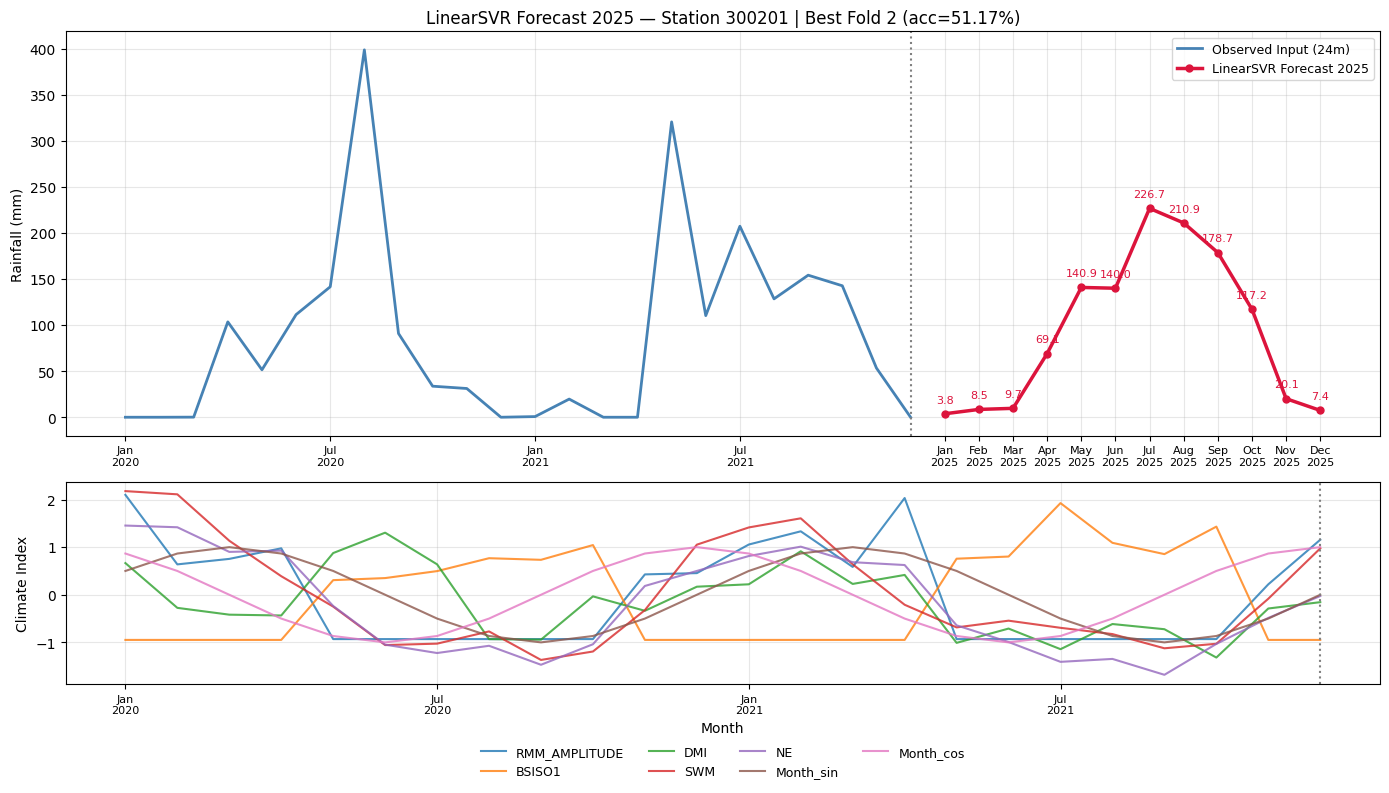

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st300201_fold2.png


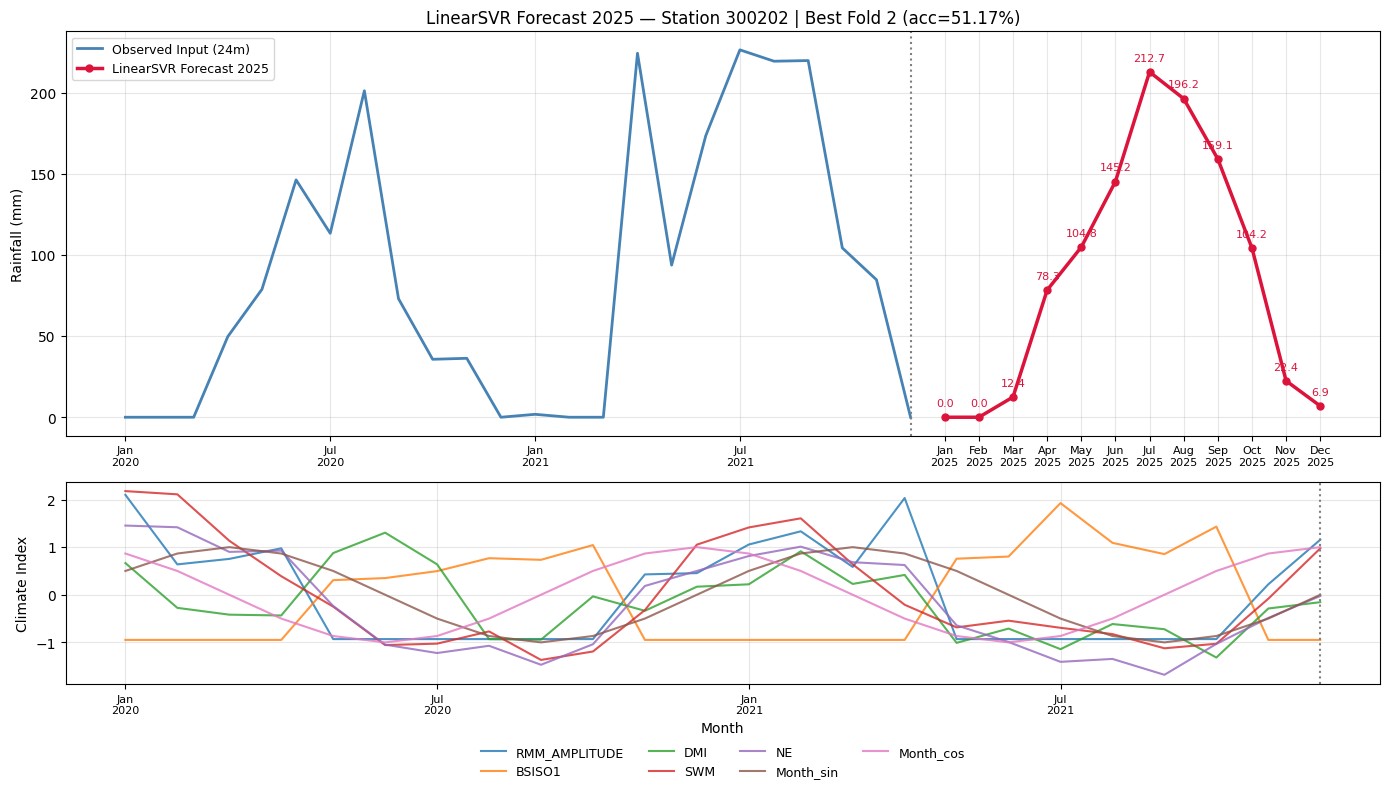

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st300202_fold2.png


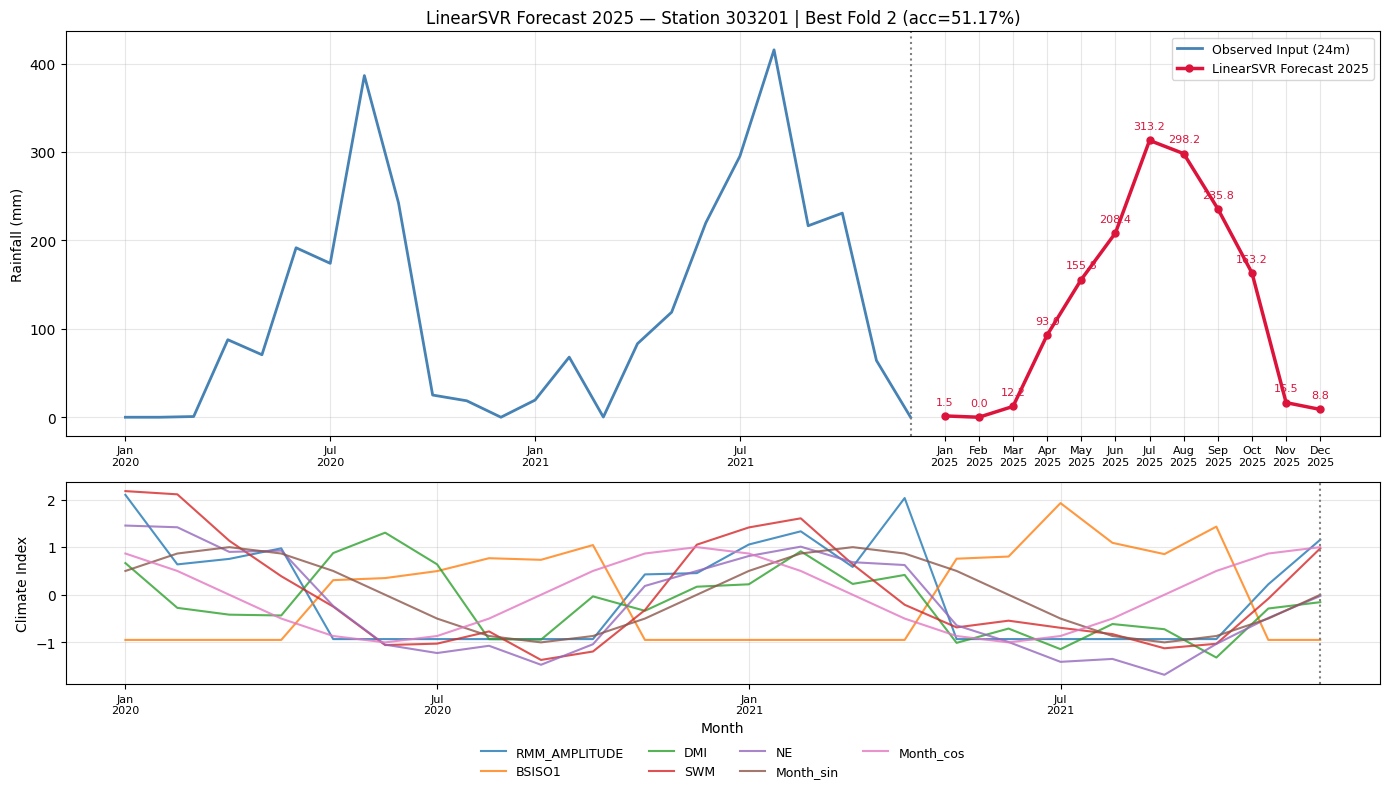

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st303201_fold2.png


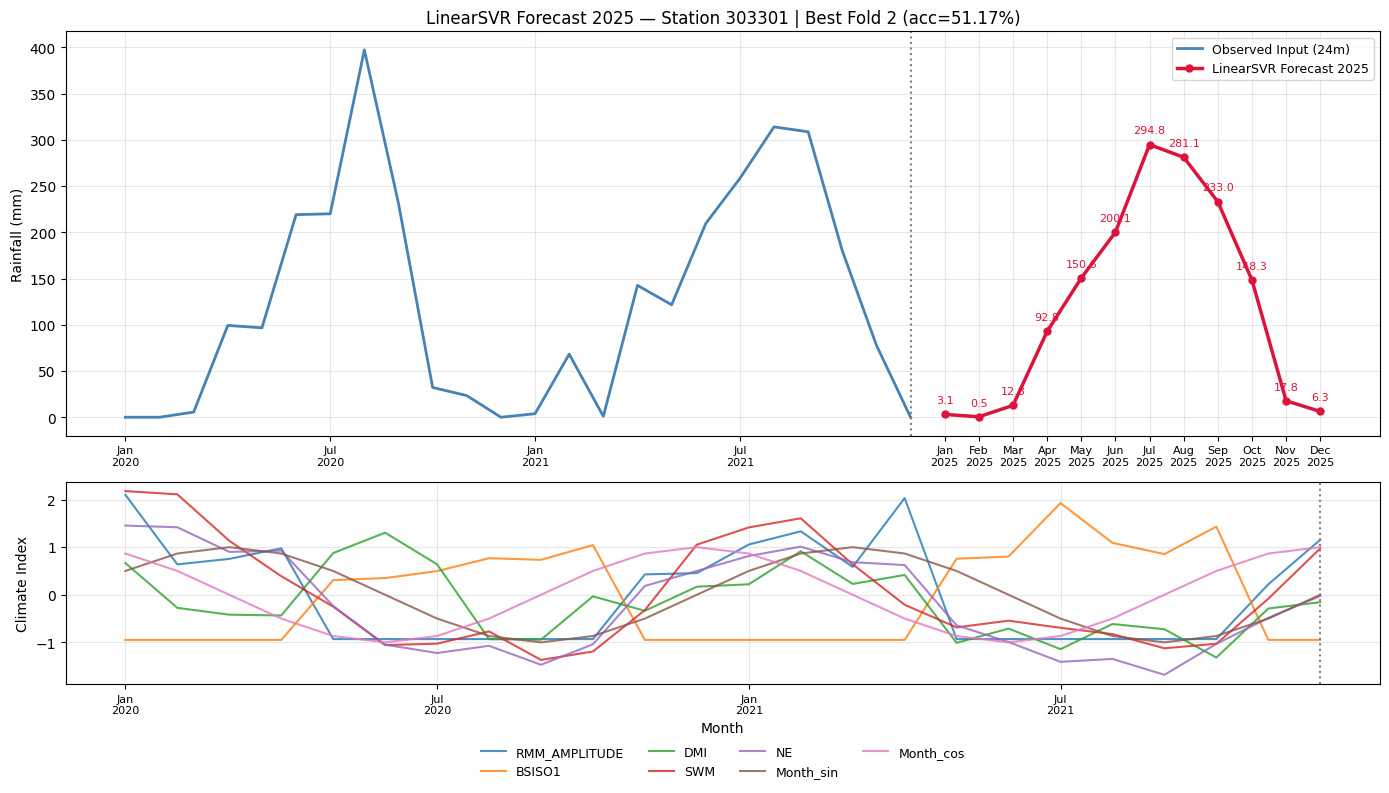

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st303301_fold2.png


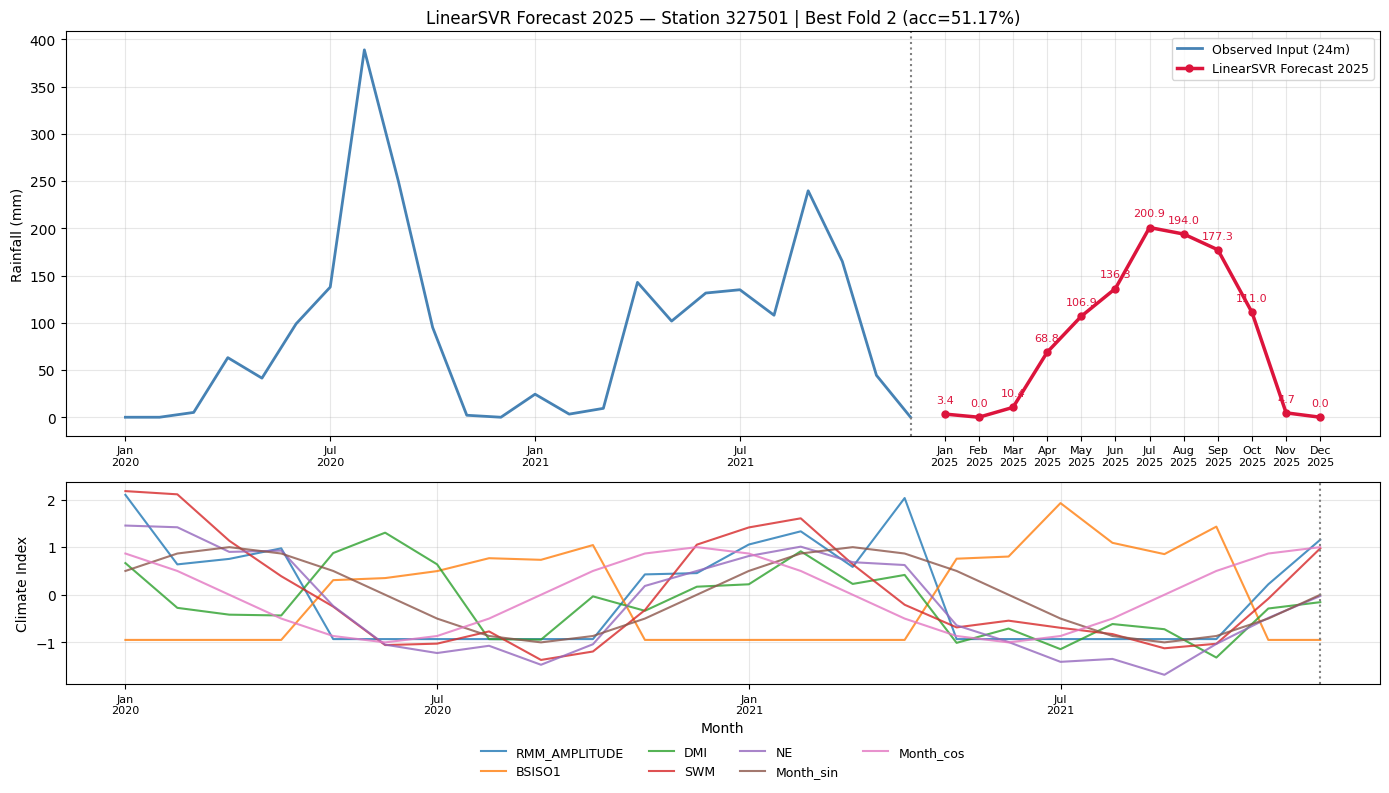

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st327501_fold2.png


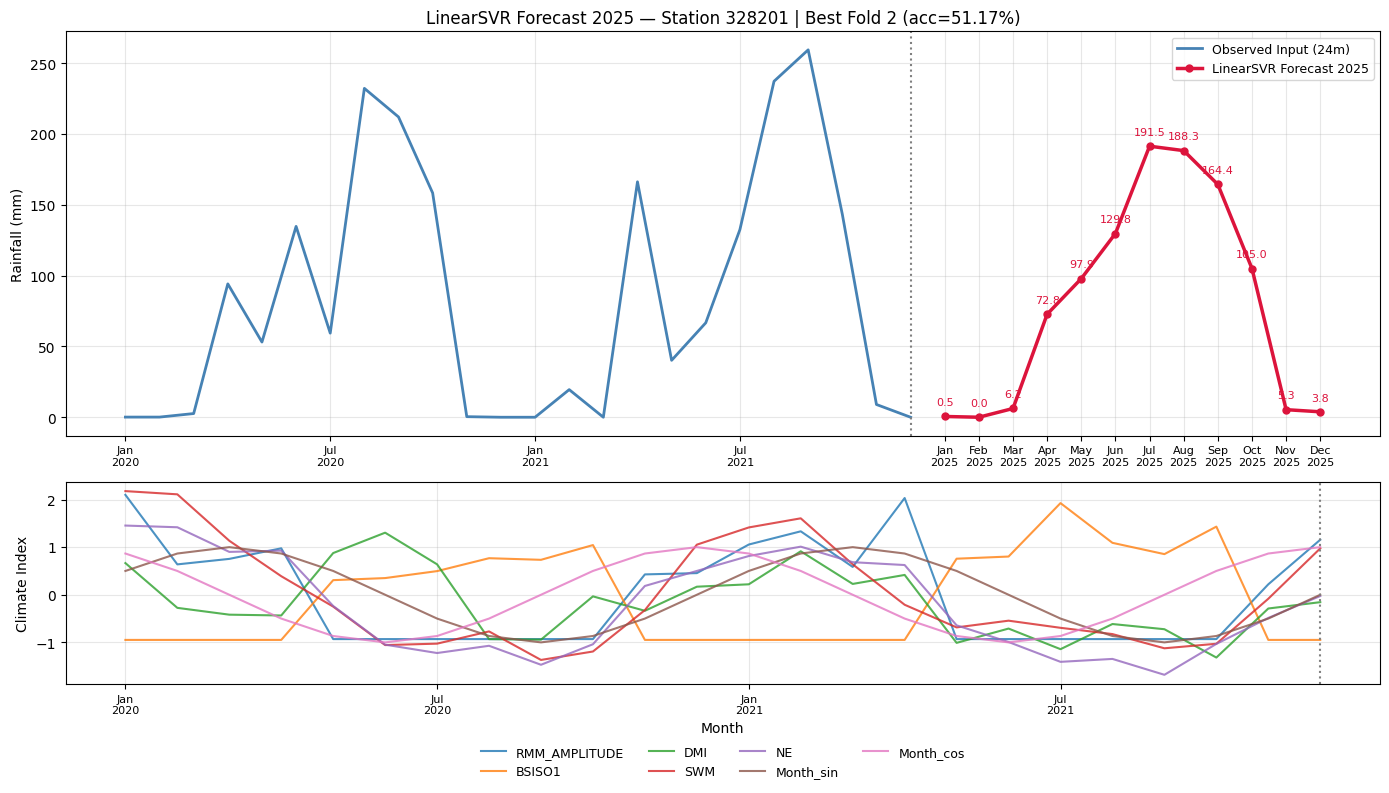

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st328201_fold2.png


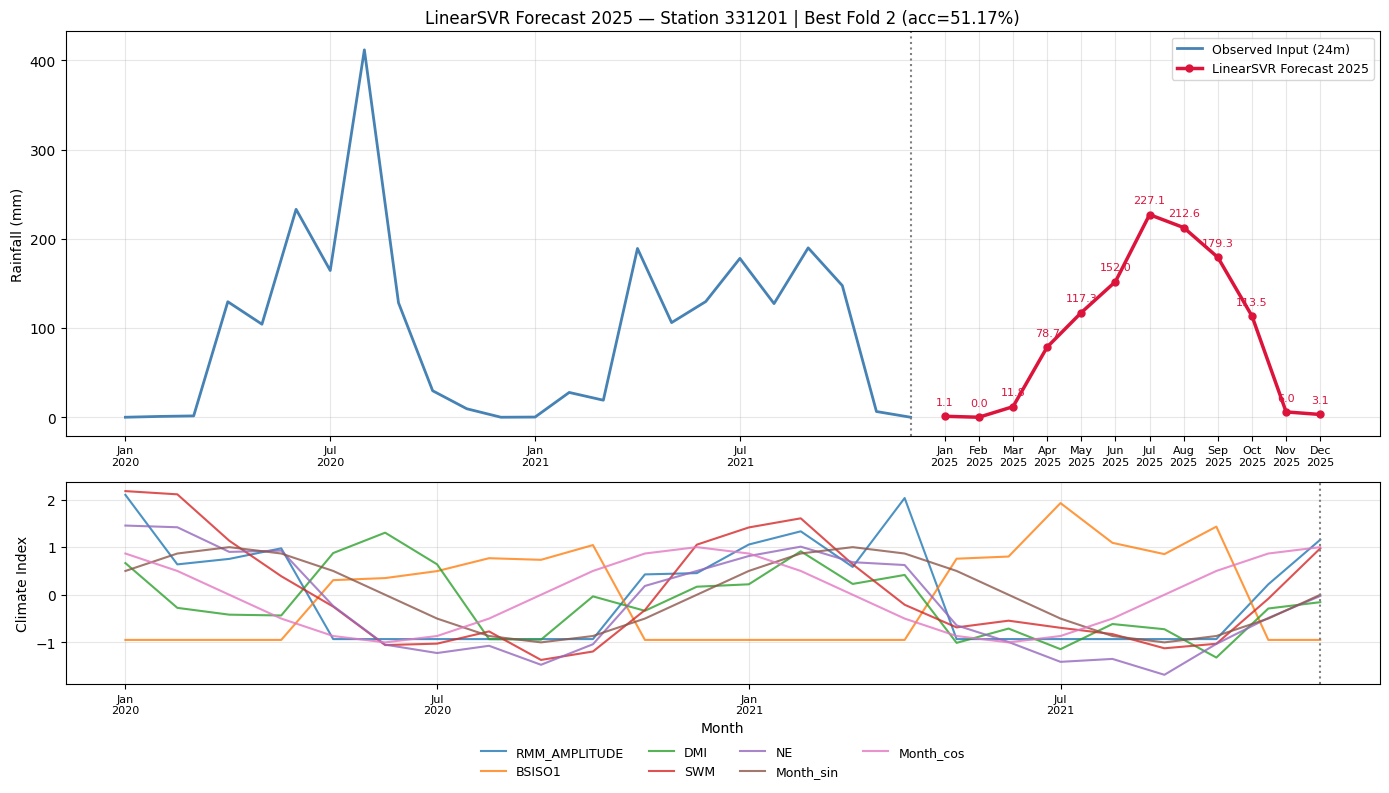

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st331201_fold2.png


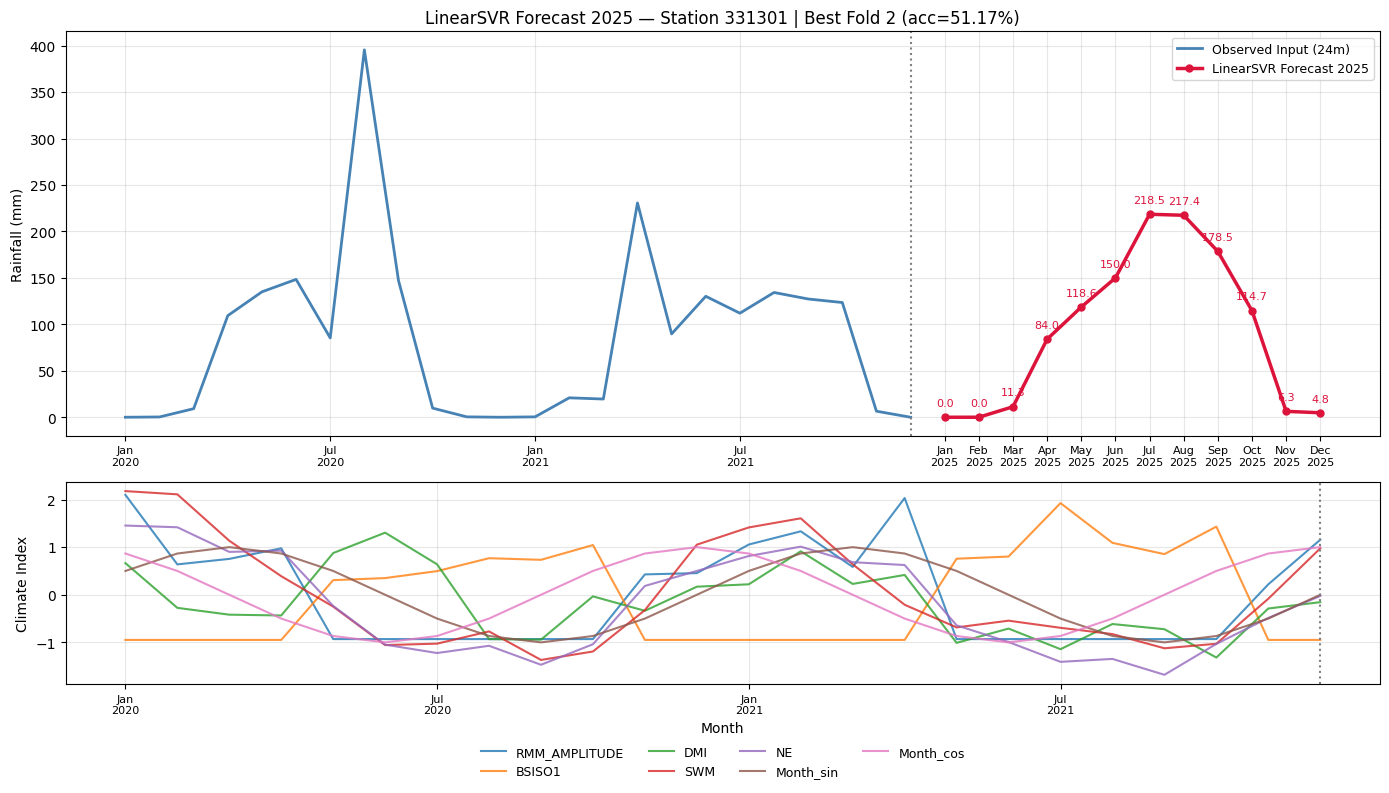

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st331301_fold2.png


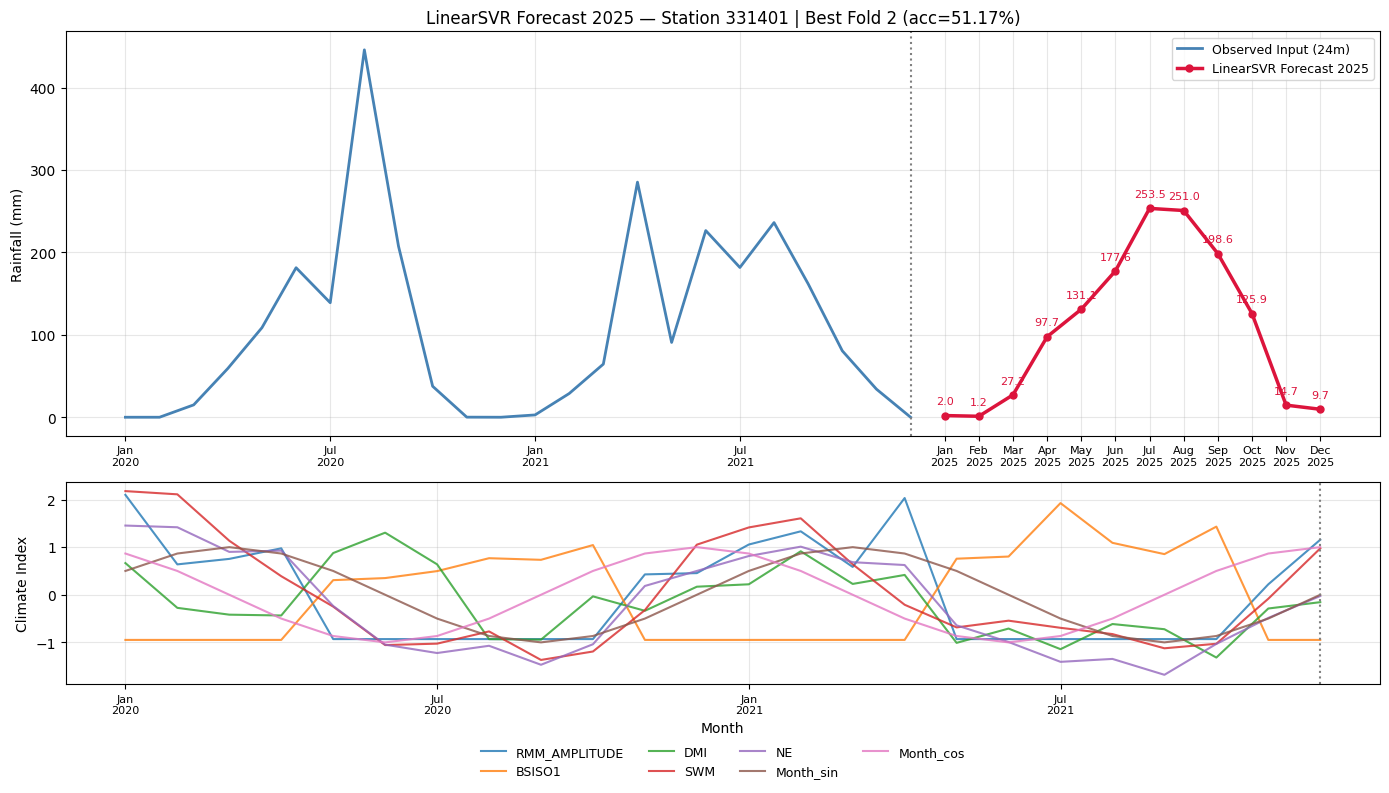

  ✓ Saved: /content/drive/MyDrive/Data_Minning/svr_results/forecast_2025_st331401_fold2.png

✓ ทำนายปี 2025 เสร็จสิ้น (9 สถานี) | Best Fold 2


In [62]:
# ════════════════════════════════════════════════════════════════
# 9. ทำนายปี 2025 — ใช้ Fold ที่ acc_test สูงสุด
# ════════════════════════════════════════════════════════════════
top_n = 20
n_st = len(cluster_station)
# ── เลือก Fold ──────────────────────────────────────
best_fold_num = int(input("เลือก Fold (1 หรือ 2): "))
best_fold_index = best_fold_num - 2

# ตรวจสอบว่าอยู่ในช่วงที่มี
assert 1 <= best_fold_num <= k_fold_num, f"กรุณาเลือก Fold 1 ถึง {k_fold_num}"

print(f"✓ ใช้ Fold: {best_fold_num}  (acc_test = {df_svr_rows[best_fold_index]['acc_test']:.4f}%)")
r_best       = all_svr_results[best_fold_index]
model_best   = r_best['model']
train_list_b = r_best['train_list']
test_list_b  = r_best['test_list']

# ── วน Loop ทุกสถานีใน Cluster ──────────────────────────────────
for st_idx in range(n_st):
    scaler_col = cluster_station[st_idx]
    st_name    = node['Node'].iloc[cluster_station[st_idx]]

    # รวม train + test → ดึง window_size เดือนสุดท้าย
    df_tr  = train_list_b[cluster_station[st_idx]]
    df_te  = test_list_b [cluster_station[st_idx]]
    df_all = pd.concat([df_tr, df_te])
    df_all = df_all[~df_all.index.duplicated(keep='last')].sort_index()

    if len(df_all) < window_size:
        print(f"  ⚠ Station {st_name}: ข้อมูลไม่พอสำหรับ window"); continue

    window_sc = df_all.iloc[-window_size:].values  # (window_size, n_cols)

    # สร้าง feature → ทำนาย Jan–Dec 2025
    base_m     = 1
    tgt_months = [(base_m - 1 + h) % 12 + 1 for h in range(horizon)]
    feat       = _make_features(window_sc, tgt_months, num_feature, climate_names_list)

    pred_sc = np.array([
        model_best.models[h].predict(feat.reshape(1, -1))[0]
        for h in range(horizon)
    ])

    # Inverse transform → mm
    rain_input_mm = inv_transform(window_sc[:, -1], scaler_col)
    pred_mm       = np.clip(inv_transform(pred_sc, scaler_col), 0, None)
    climate_input = window_sc[:, :num_feature]

    # ── label แกน X ─────────────────────────────────────────────
    last_date     = df_all.index[-1]
    input_dates   = df_all.index[-window_size:]
    input_labels  = [d.strftime('%b\n%Y') if i % 6 == 0 else ''
                     for i, d in enumerate(input_dates)]
    pred_dates    = pd.date_range('2025-01-01', periods=horizon, freq='MS')
    pred_labels   = [d.strftime('%b\n%Y') for d in pred_dates]

    t_input = np.arange(1, window_size + 1)
    t_pred  = np.arange(window_size + 1, window_size + horizon + 1)

    # ════════════════════════════════════════════════════════════
    # กราฟ (เหมือน Section 6: 2 แผง บน=ฝน ล่าง=climate)
    # ════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                             gridspec_kw={'height_ratios': [2, 1]})

    # ── แผงบน: Rainfall ─────────────────────────────────────────
    axes[0].plot(t_input, rain_input_mm,
                 label=f'Observed Input ({window_size}m)',
                 linewidth=2, color='steelblue')
    axes[0].plot(t_pred, pred_mm,
                 label='LinearSVR Forecast 2025',
                 linewidth=2.5, color='crimson',
                 marker='o', markersize=5)
    axes[0].axvline(window_size, color='gray', linestyle=':', linewidth=1.5)

    # ป้ายค่า mm เหนือจุดทำนาย
    for xp, yp in zip(t_pred, pred_mm):
        axes[0].annotate(f'{yp:.1f}',
                         xy=(xp, yp), xytext=(0, 8),
                         textcoords='offset points',
                         ha='center', fontsize=8, color='crimson')

    # แกน X รวม input + forecast
    all_ticks  = list(t_input[::6]) + list(t_pred)
    all_labels = [input_labels[i] for i in range(0, window_size, 6)] + pred_labels
    axes[0].set_xticks(all_ticks)
    axes[0].set_xticklabels(all_labels, fontsize=8)
    axes[0].set_ylabel('Rainfall (mm)')
    axes[0].set_title(
        f'LinearSVR Forecast 2025 — Station {st_name} | Best Fold {best_fold_num} '
        f'(acc={df_svr_rows[best_fold_index]["acc_test"]:.2f}%)'
    )
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # ── แผงล่าง: Climate index ───────────────────────────────────
    for i, cname in enumerate(climate_name_list):
        axes[1].plot(t_input, climate_input[:, i],
                     linewidth=1.5, alpha=0.8, label=cname)
    axes[1].axvline(window_size, color='gray', linestyle=':', linewidth=1.5)
    axes[1].set_xticks(list(t_input[::6]))
    axes[1].set_xticklabels([input_labels[i] for i in range(0, window_size, 6)], fontsize=8)
    axes[1].set_ylabel('Climate Index')
    axes[1].set_xlabel('Month')
    axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
                   ncol=min(4, len(climate_name_list)), fontsize=9, frameon=False)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(SVR_SAVE_DIR, f'forecast_2025_st{st_name}_fold{best_fold_num}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  ✓ Saved: {save_path}")

print(f"\n✓ ทำนายปี 2025 เสร็จสิ้น ({n_st} สถานี) | Best Fold {best_fold_num}")

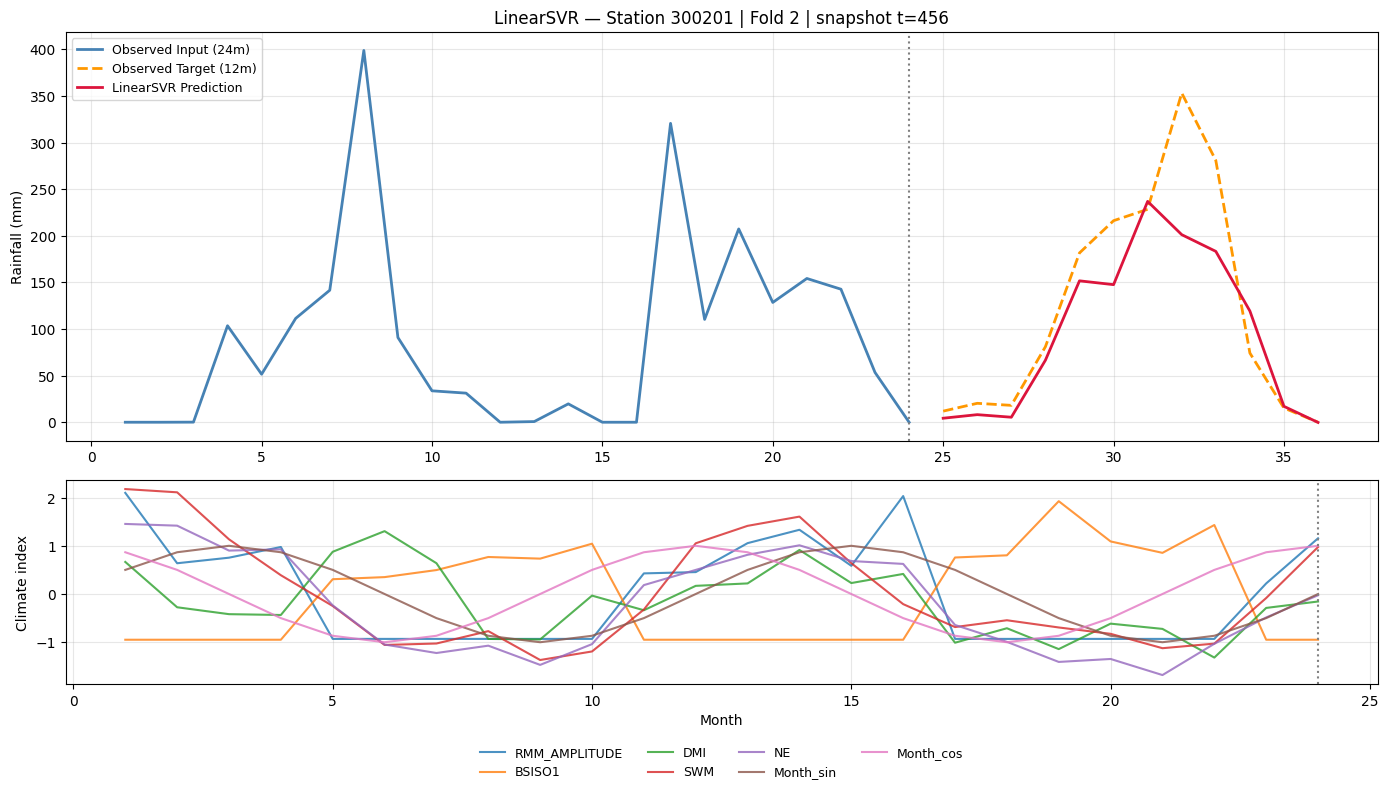

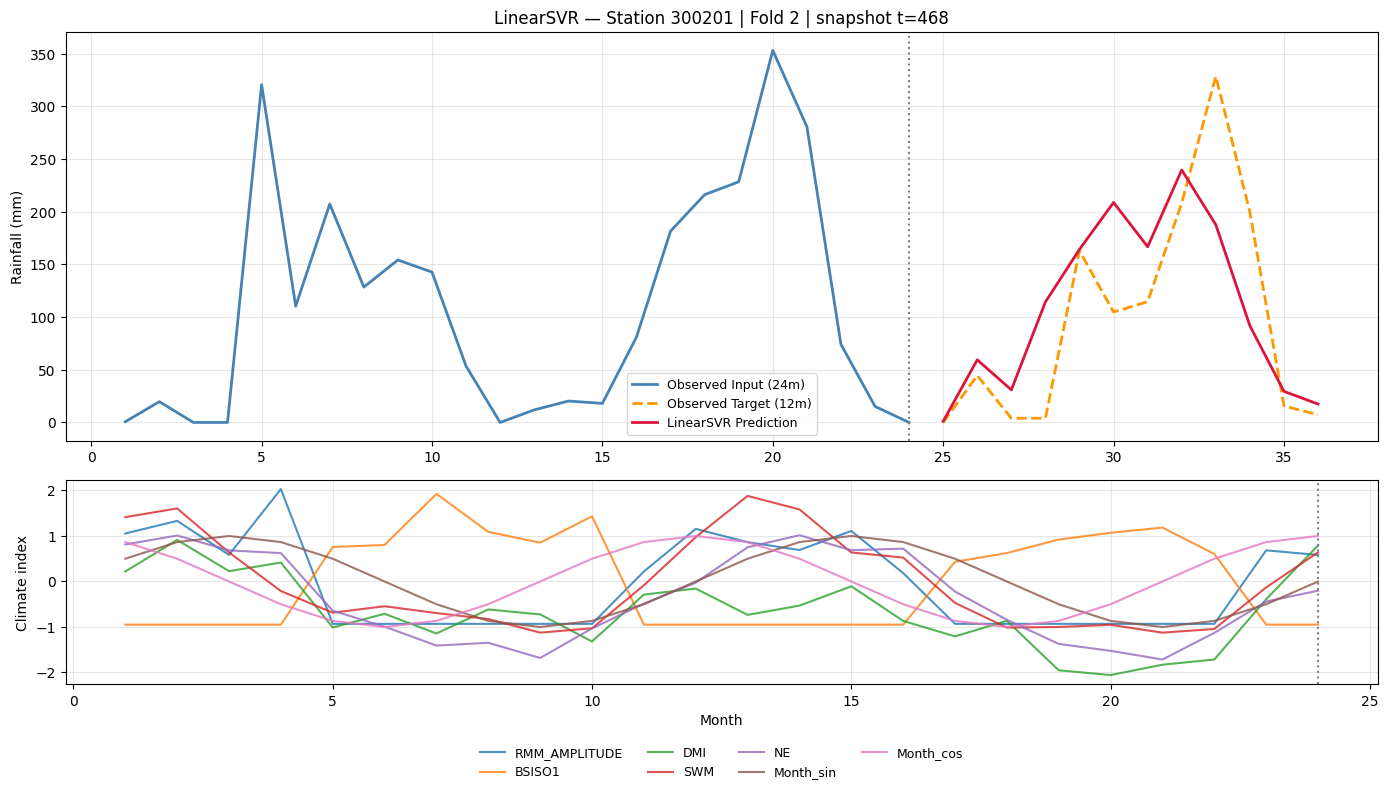

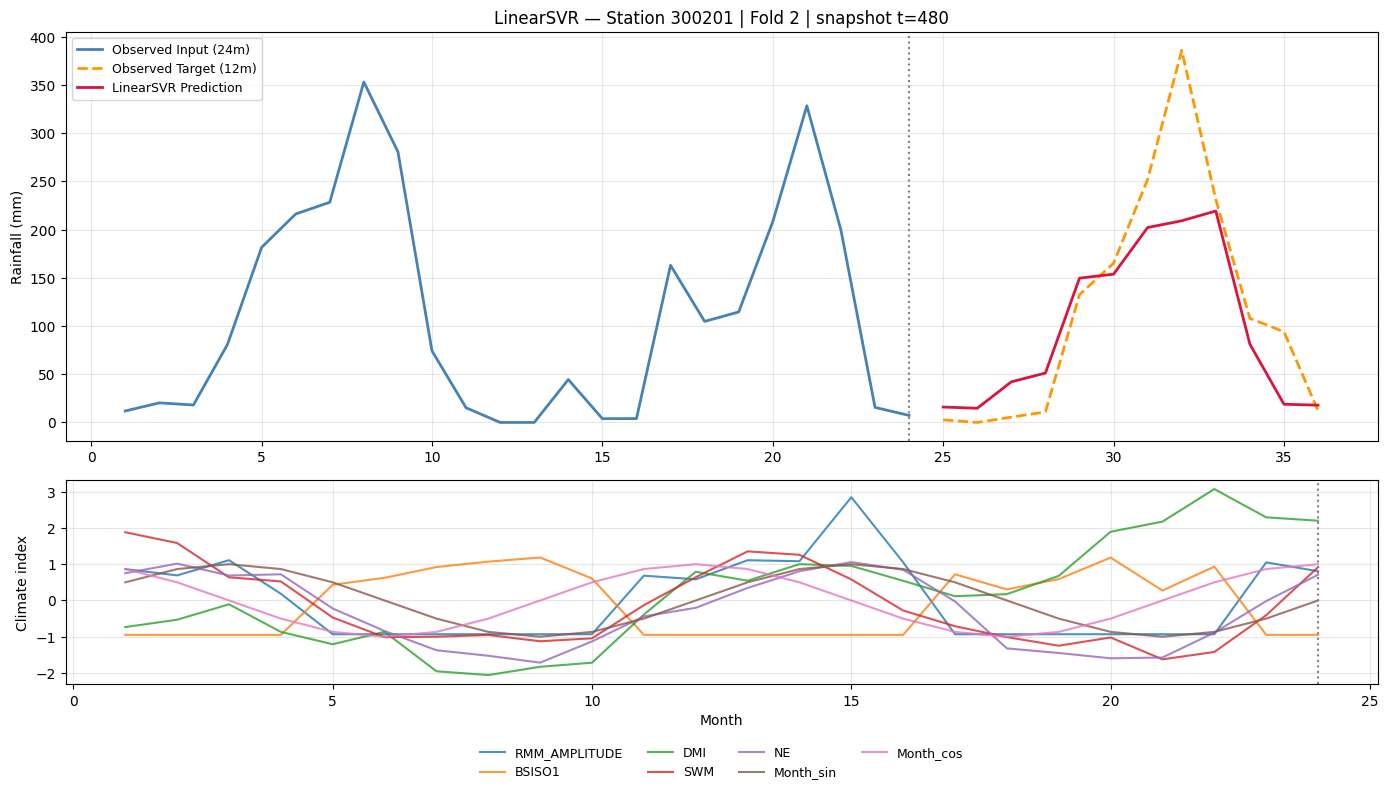

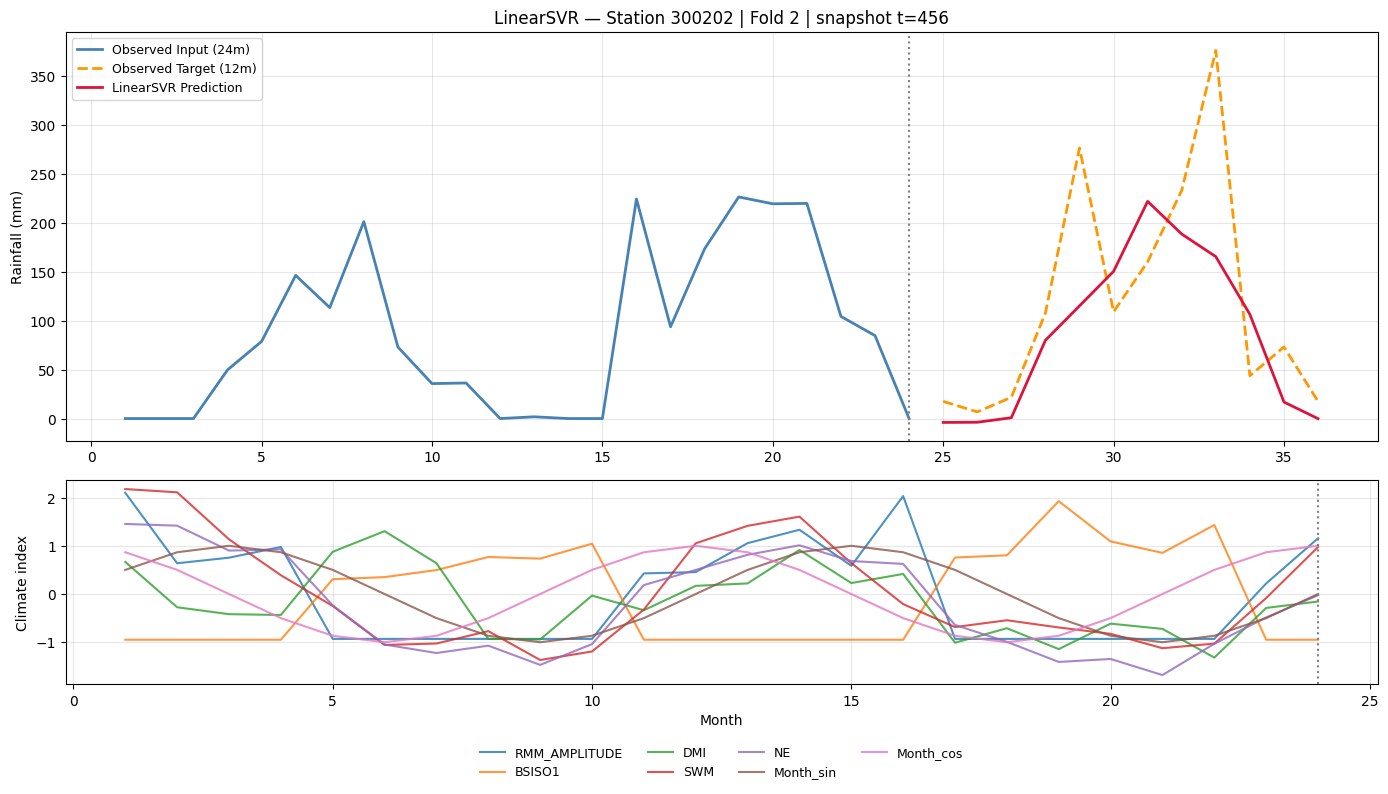

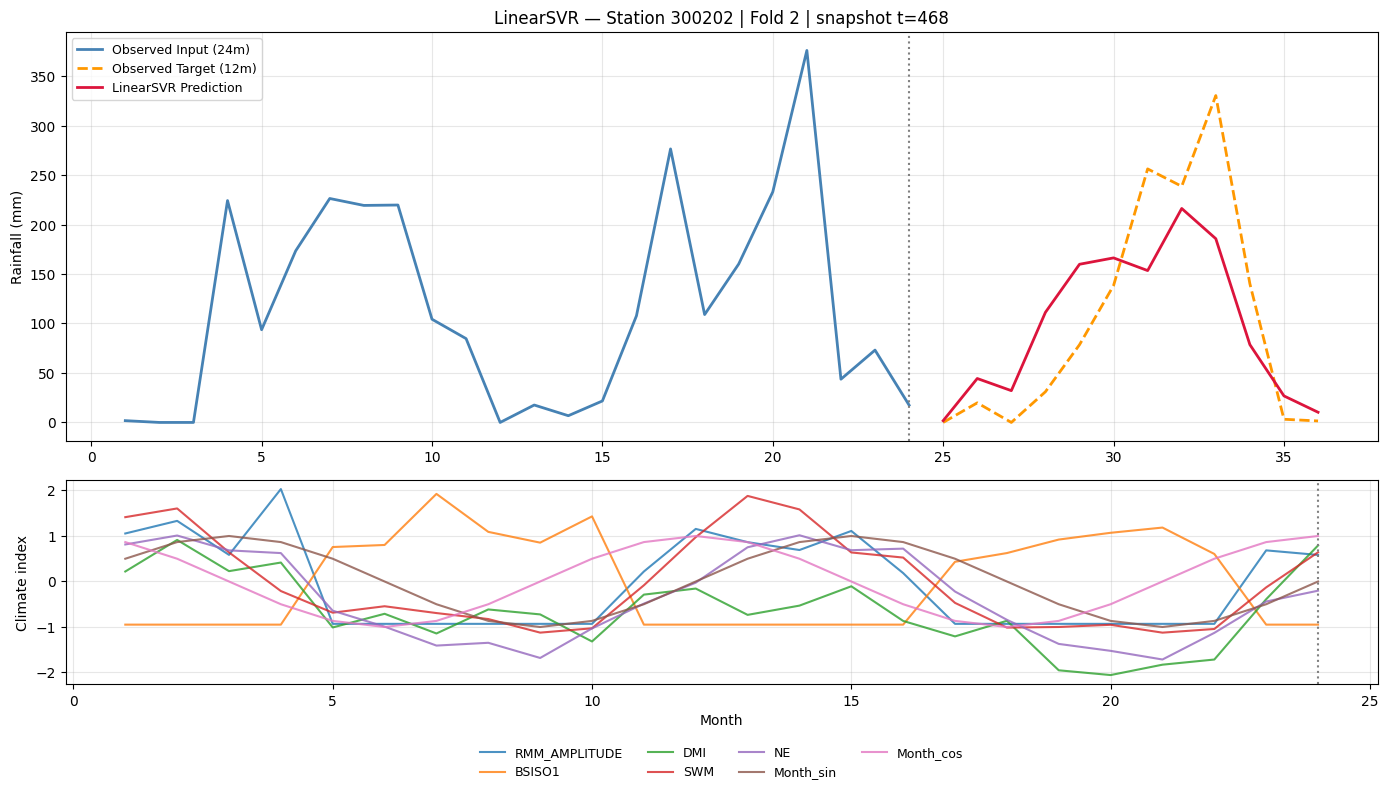

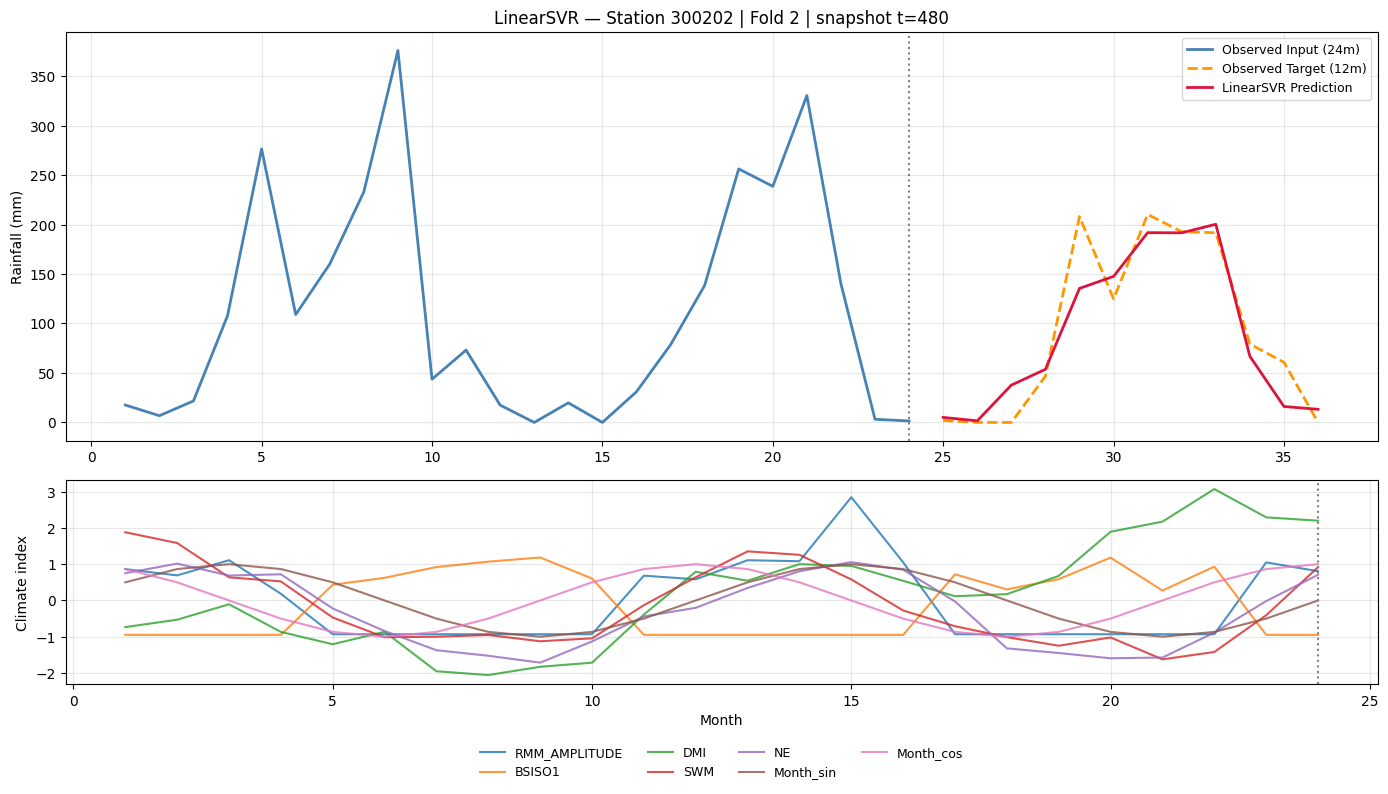

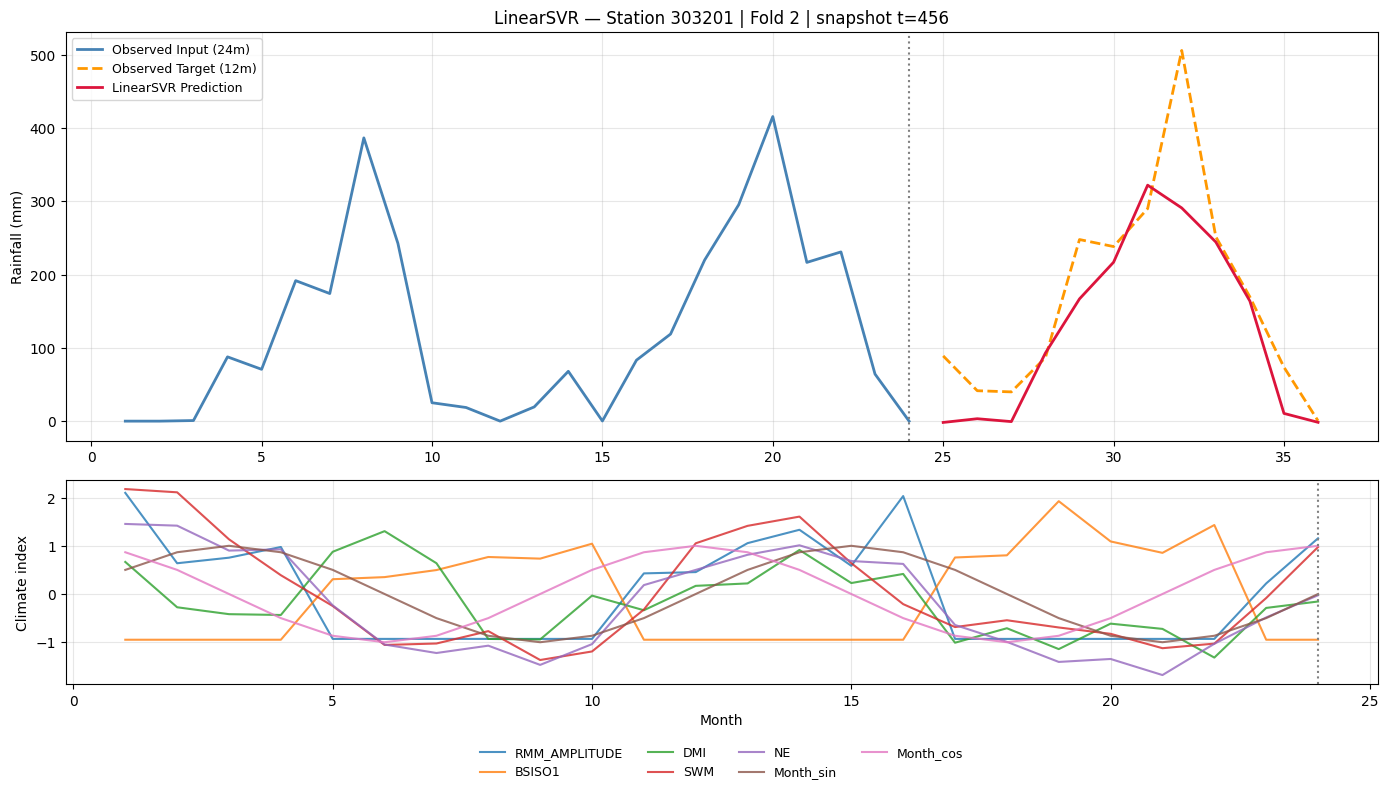

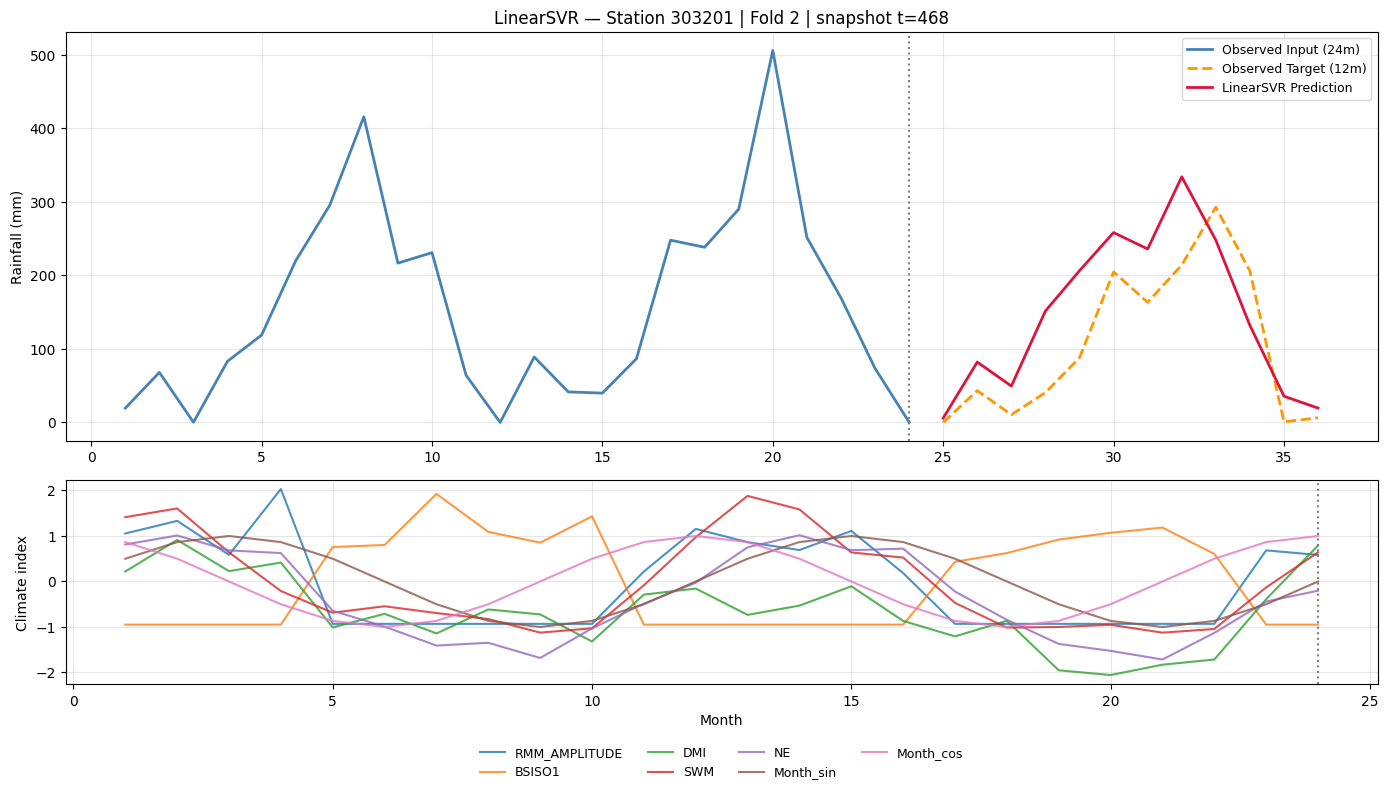

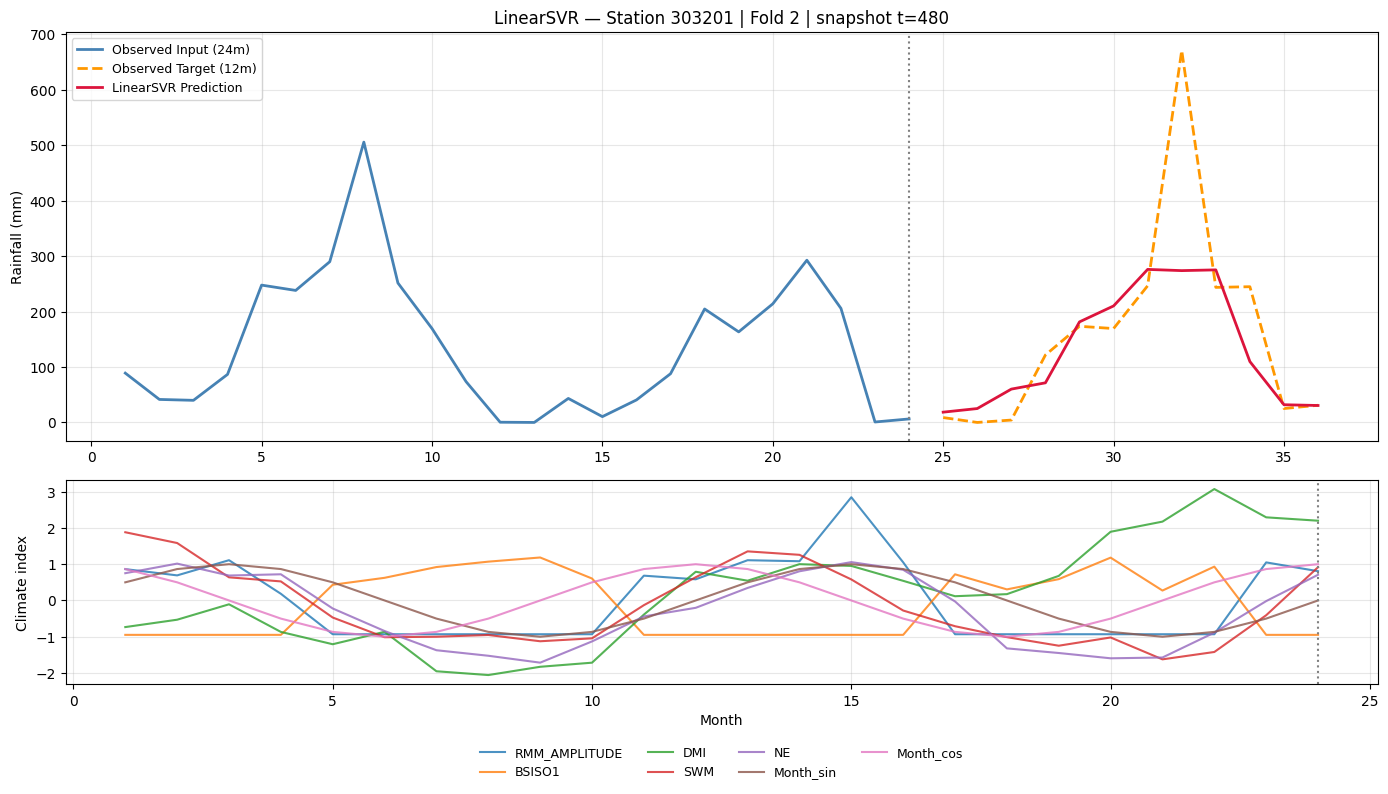

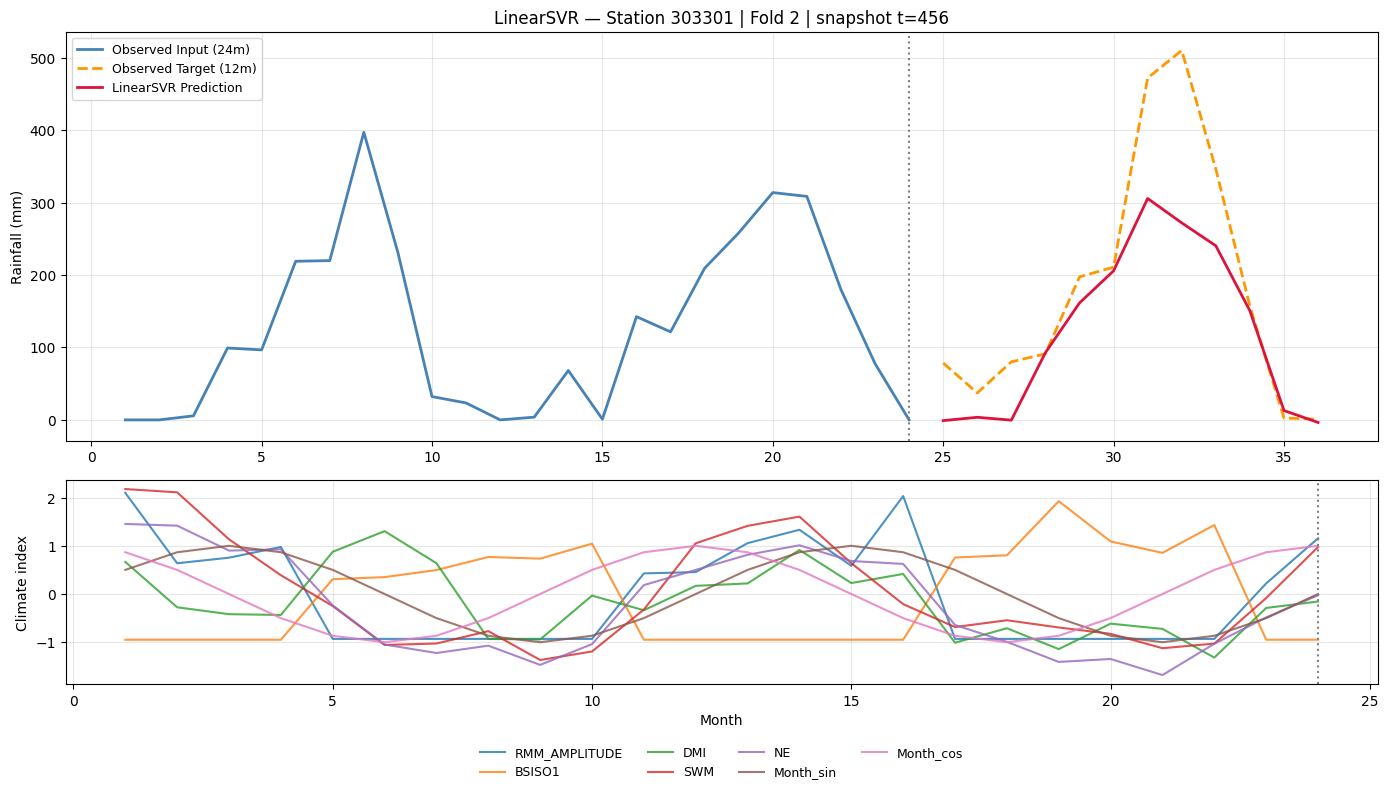

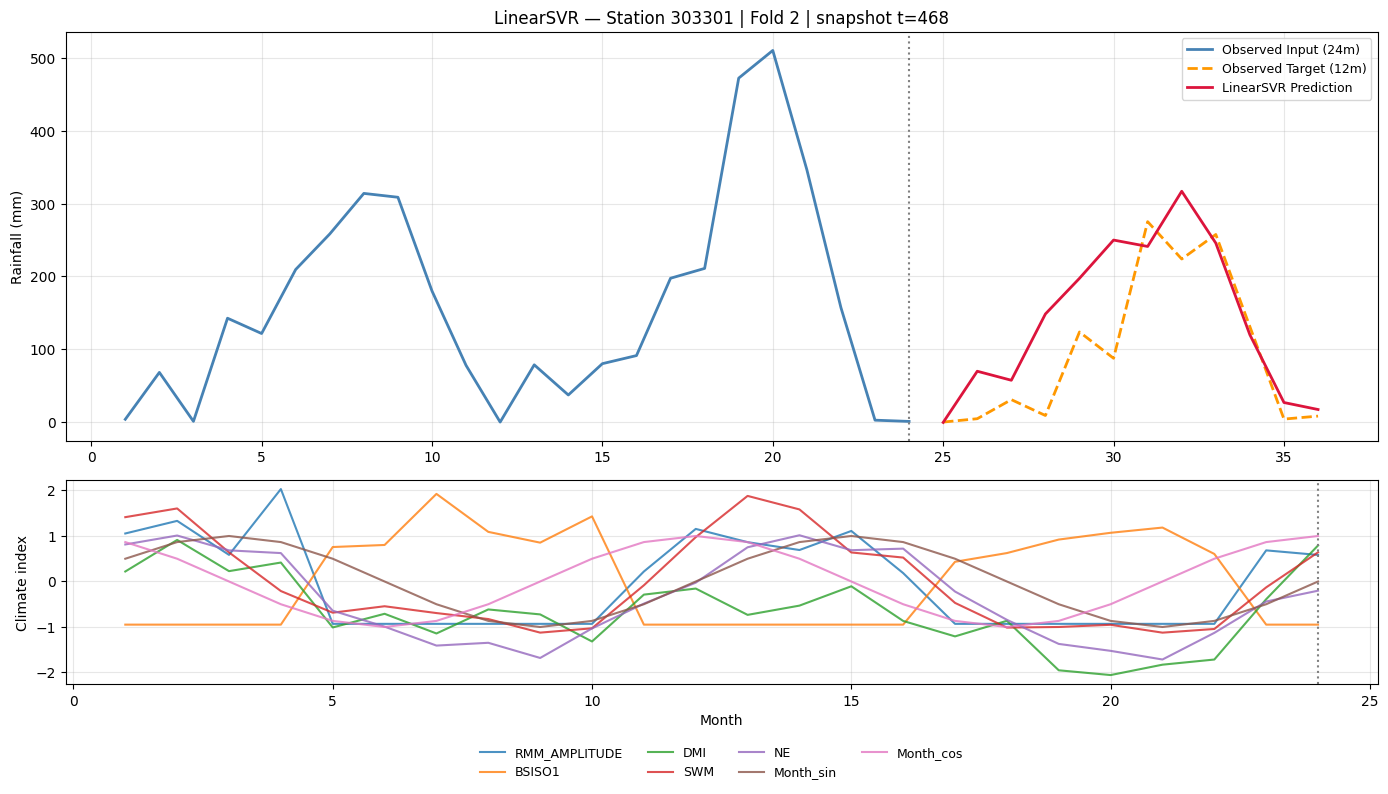

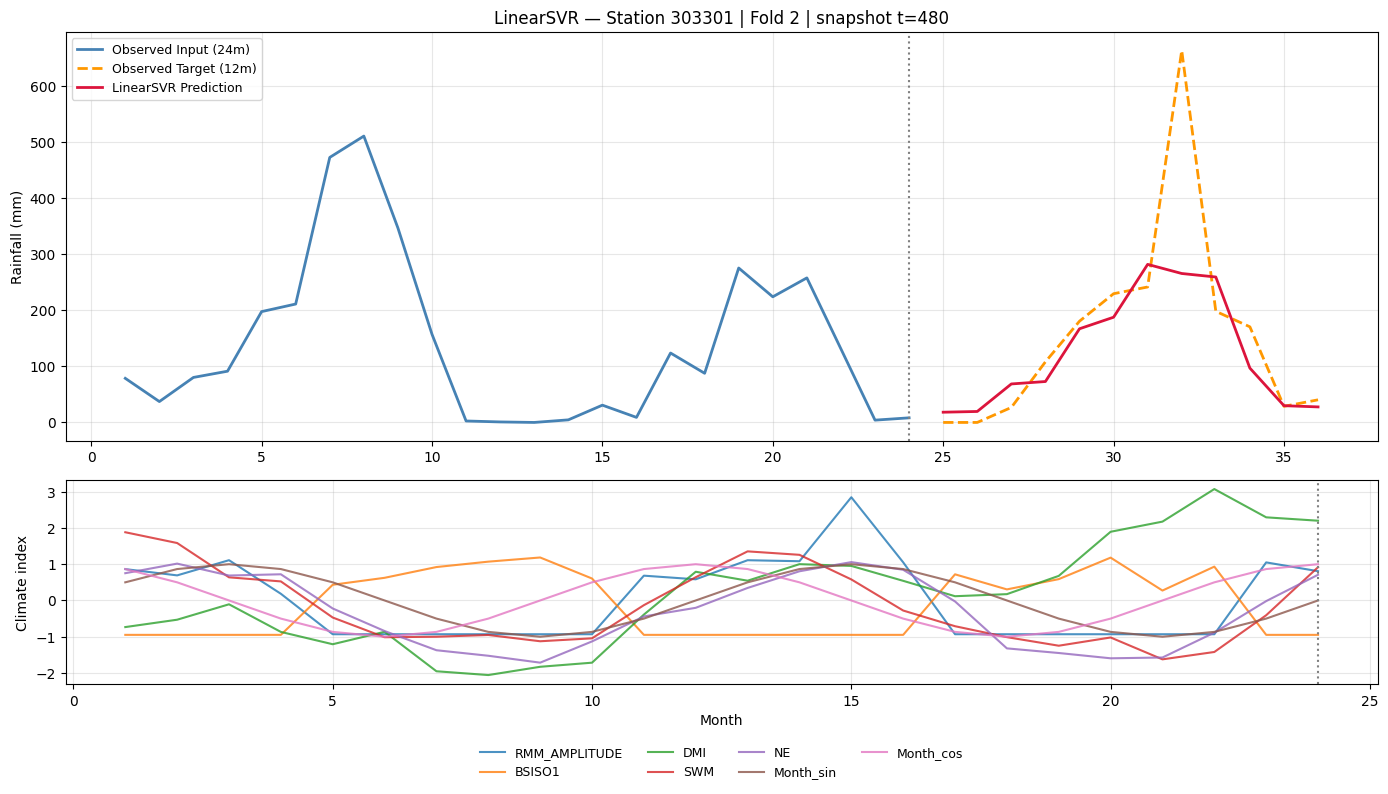

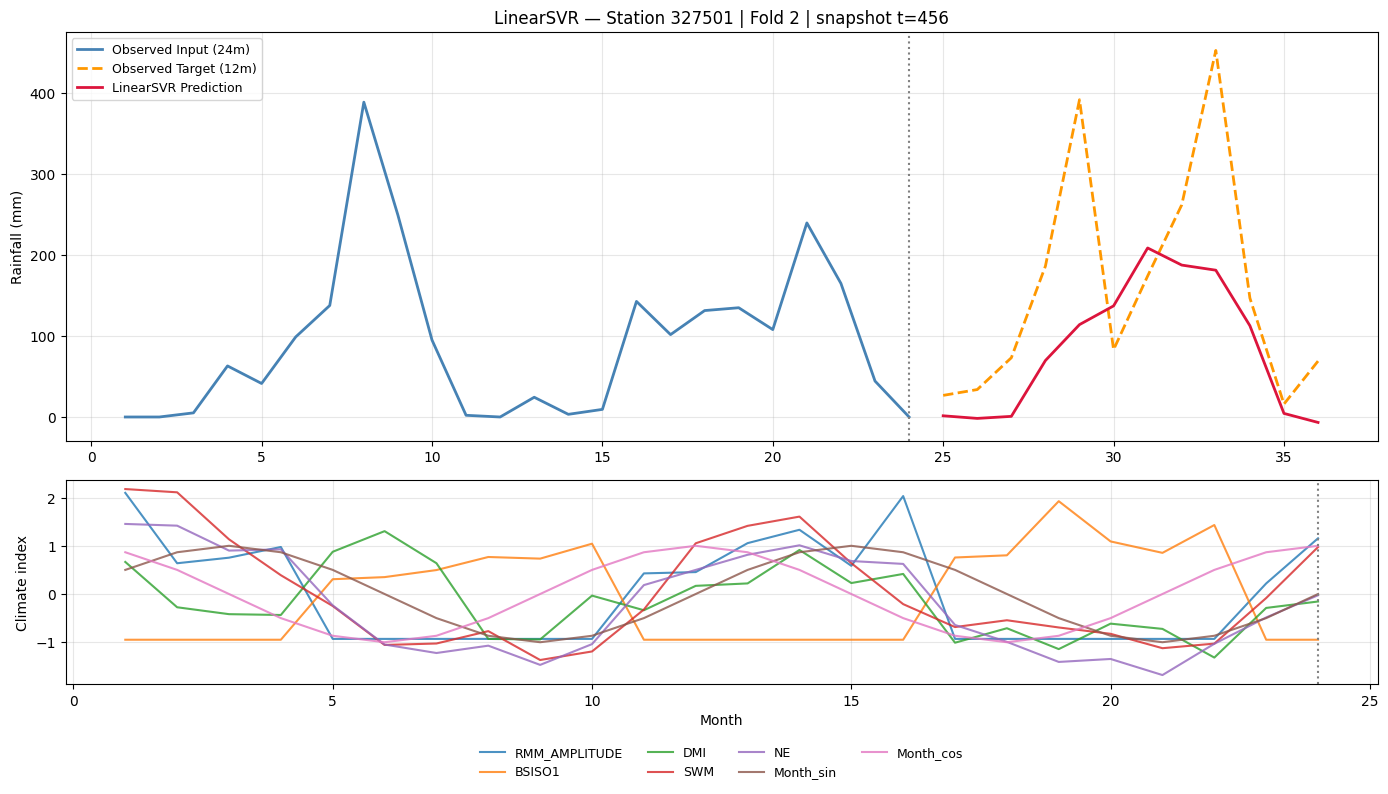

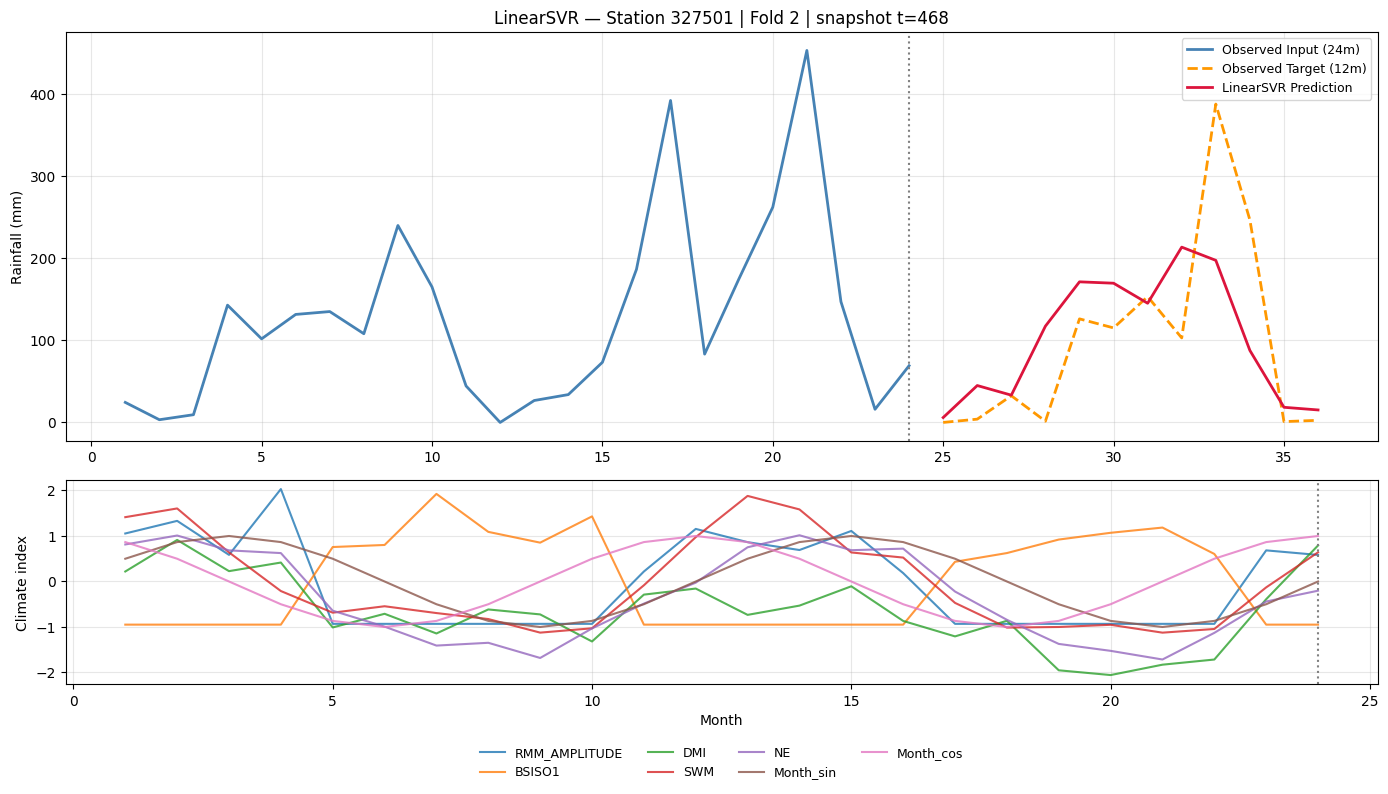

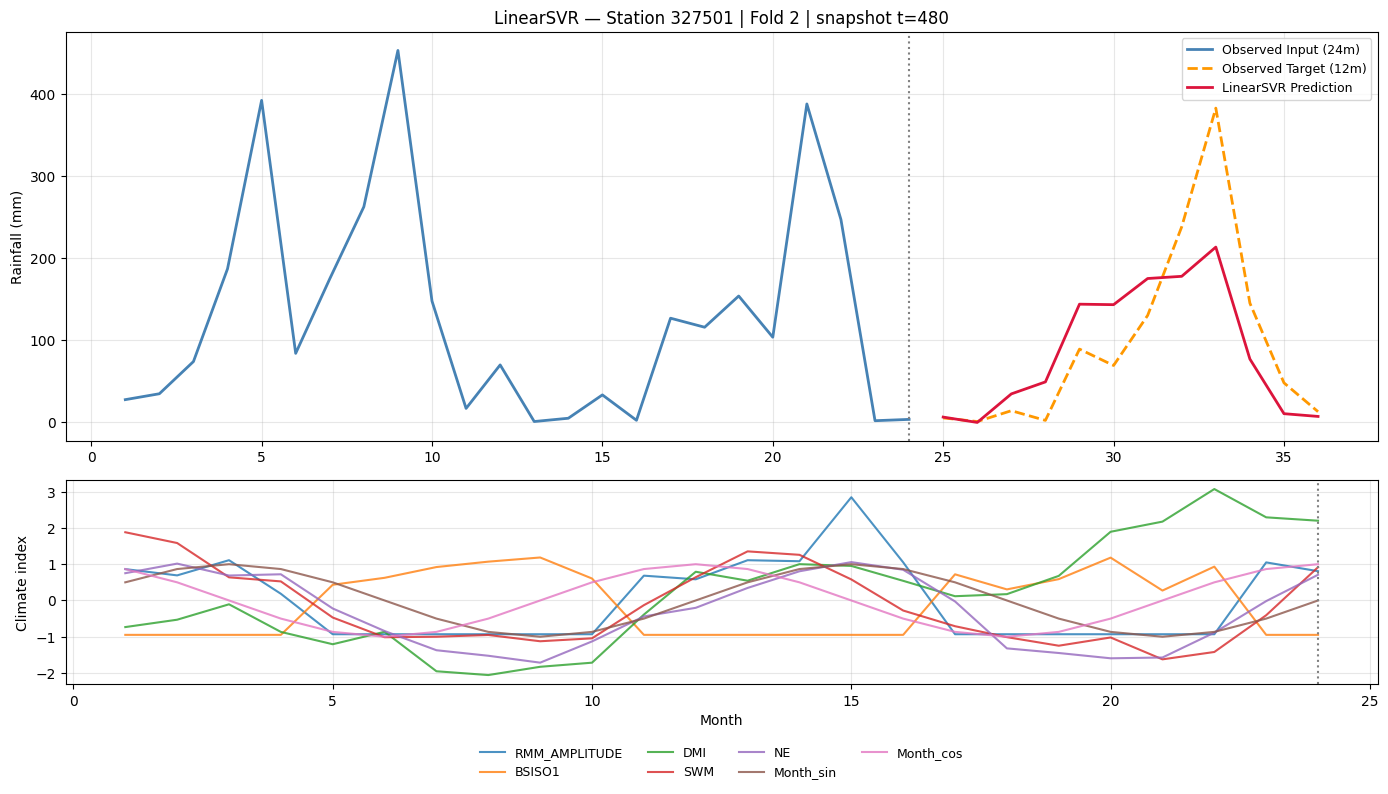

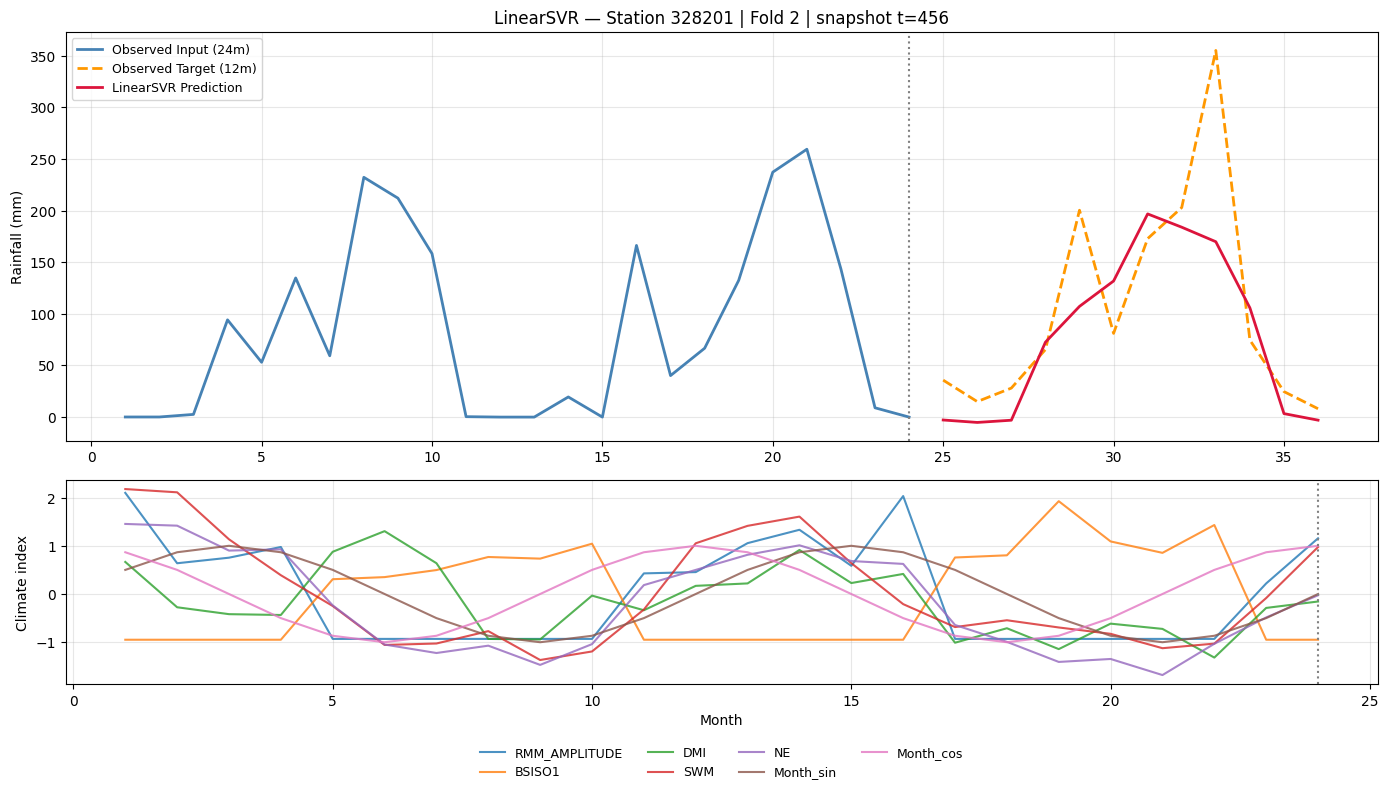

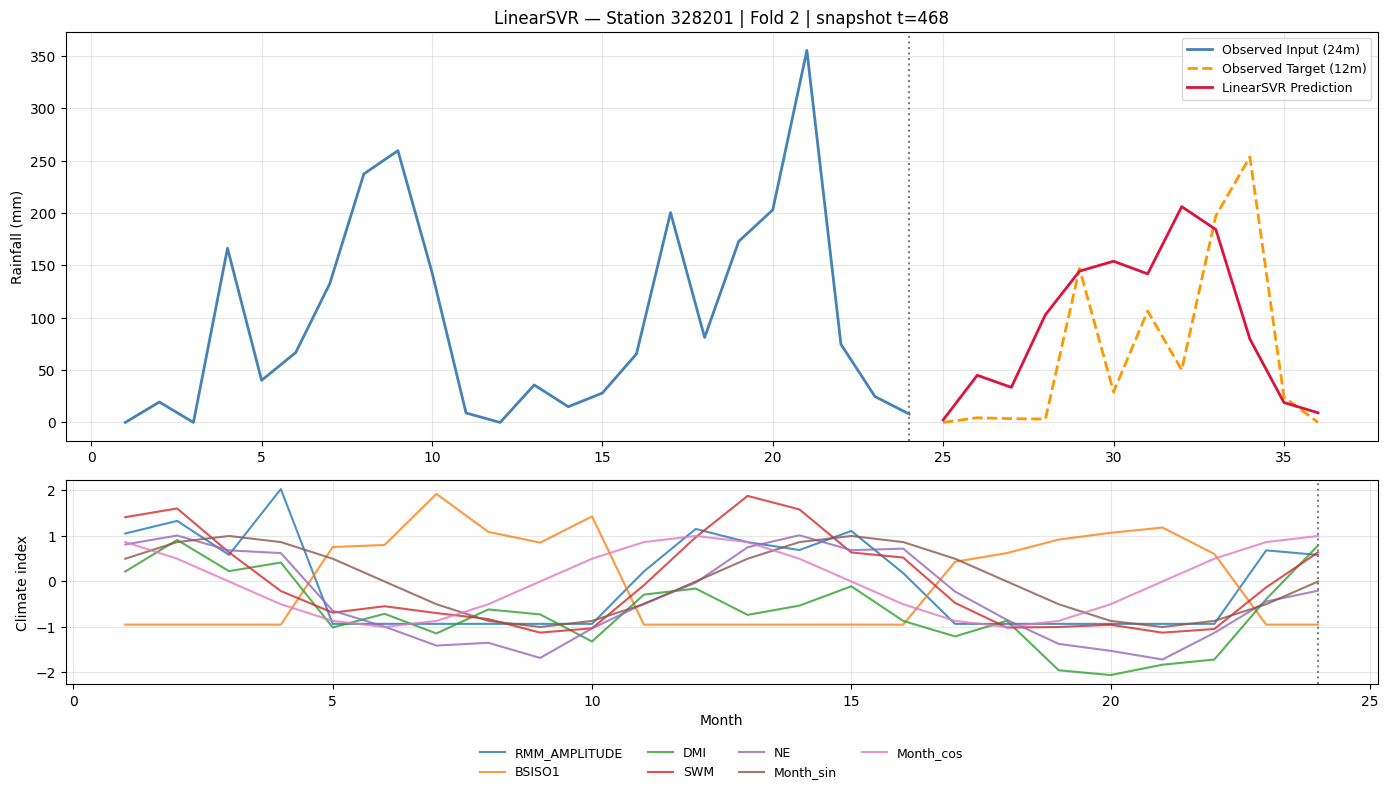

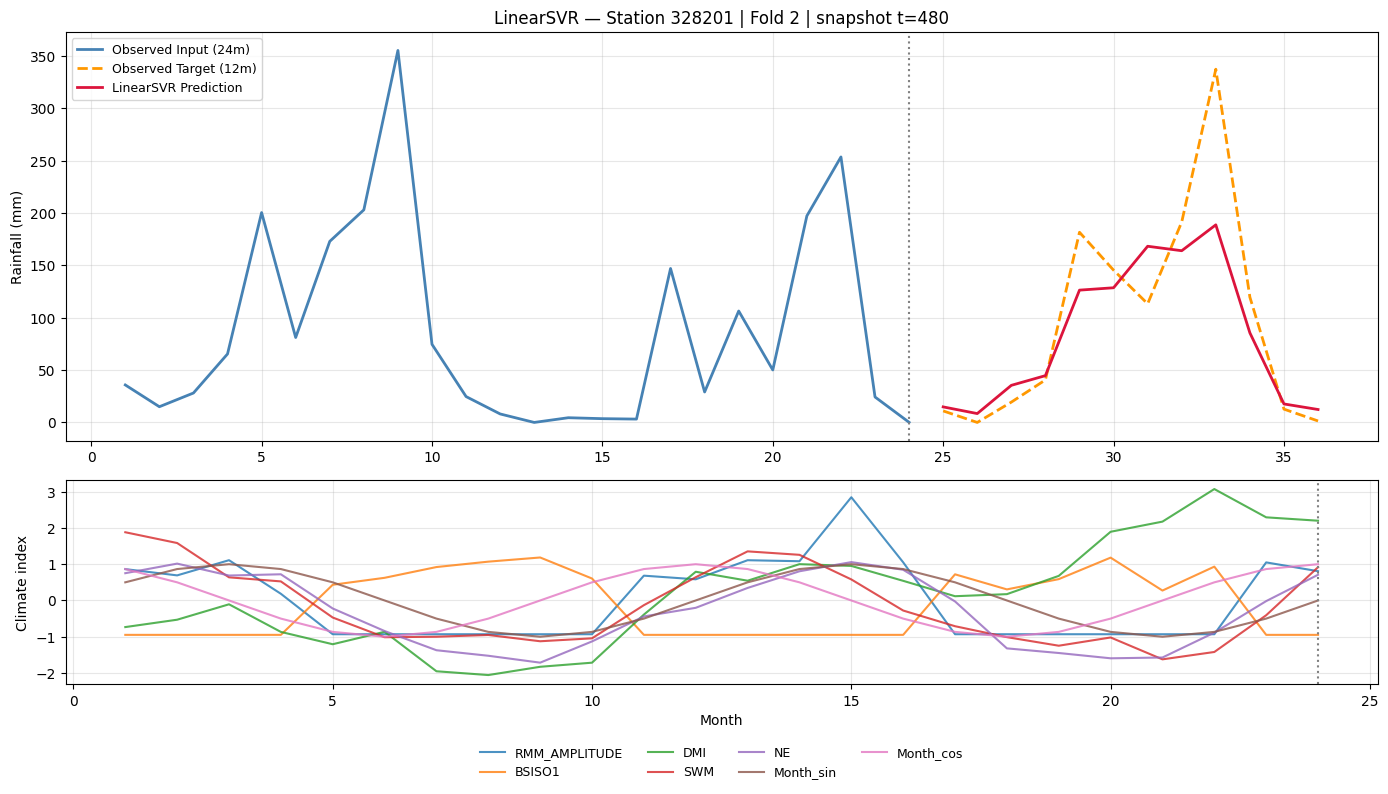

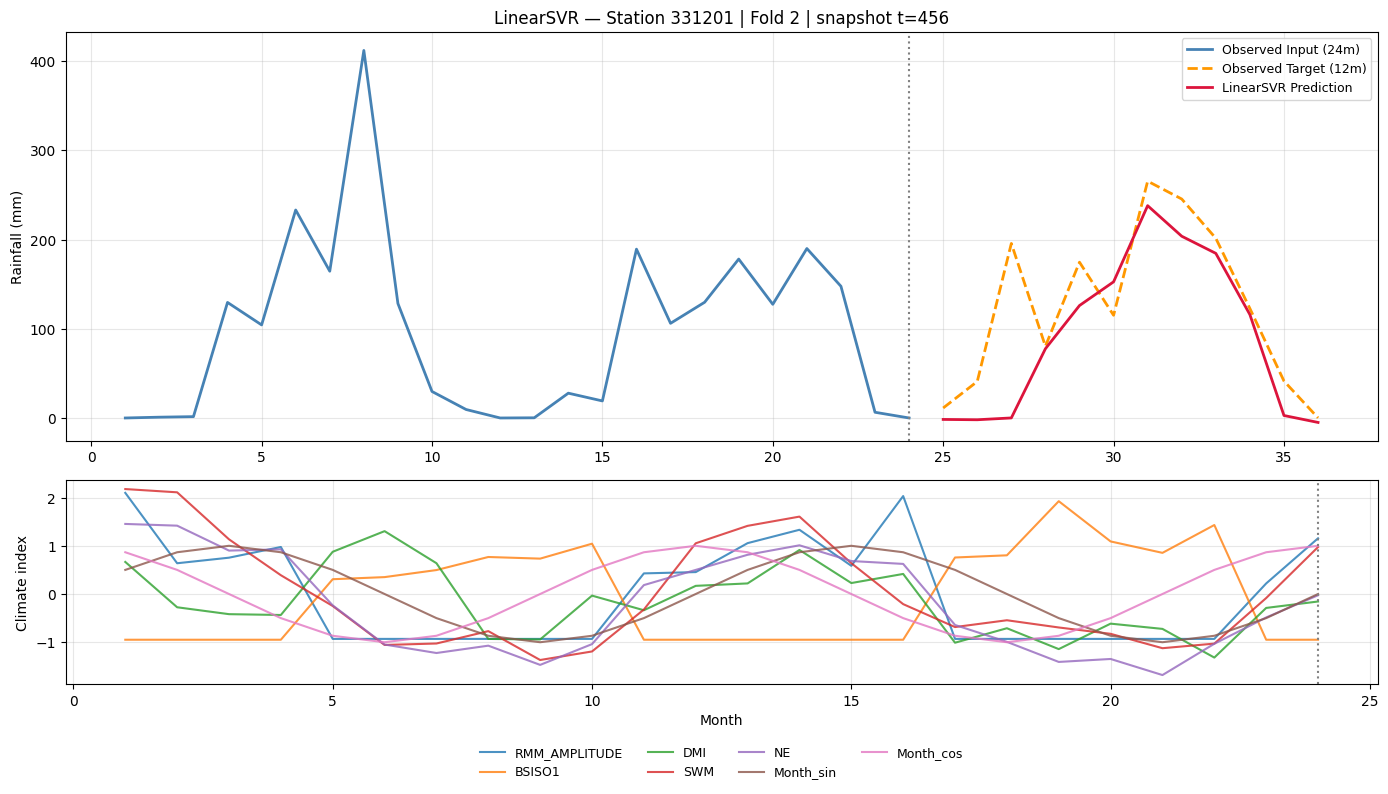

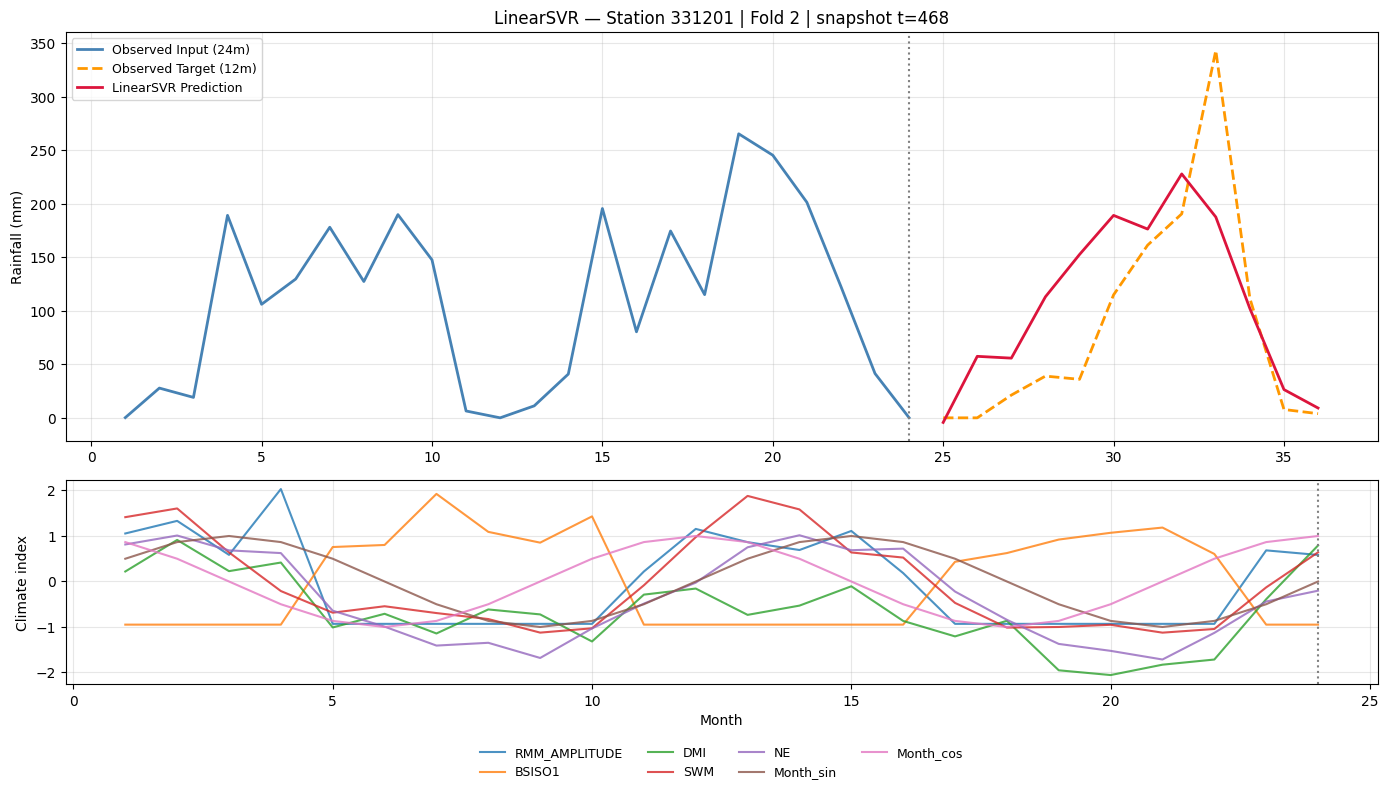

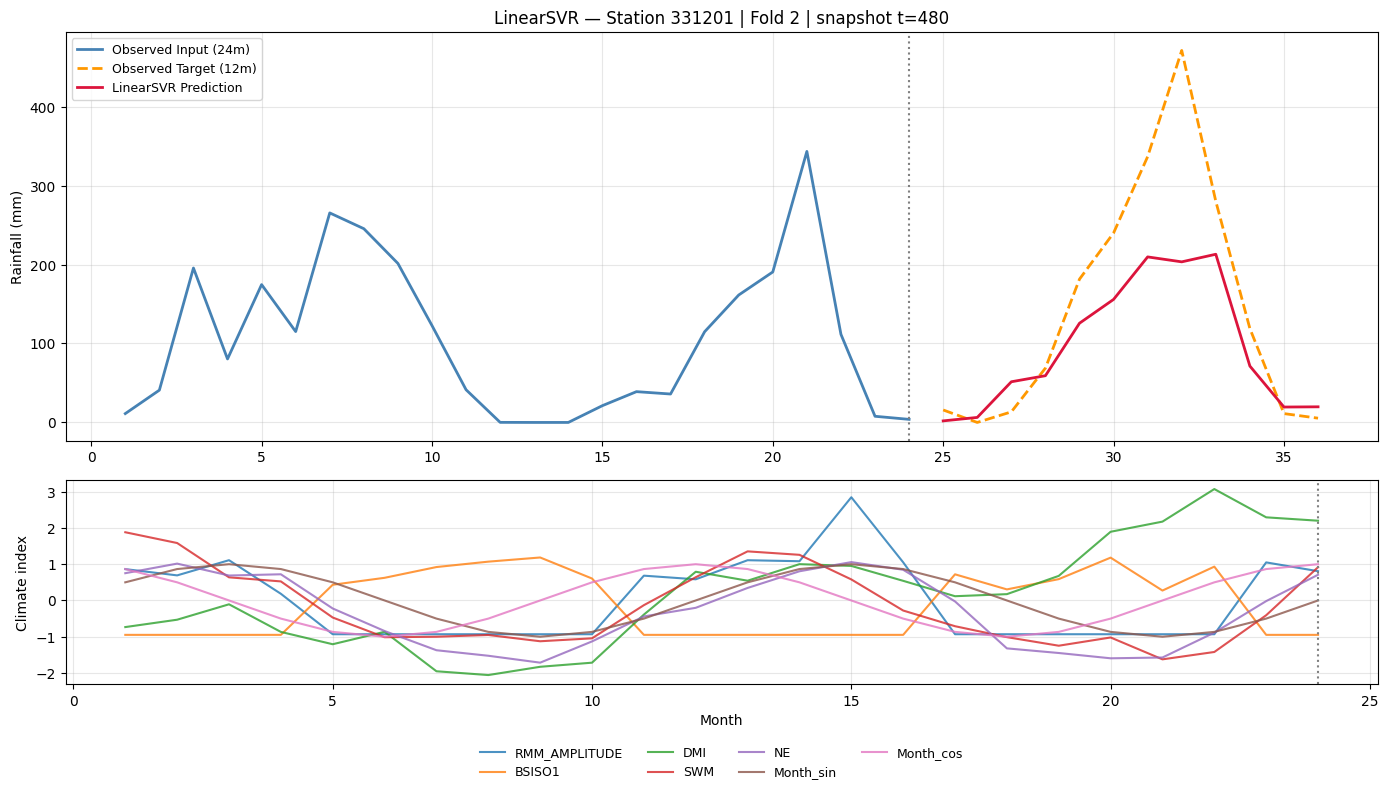

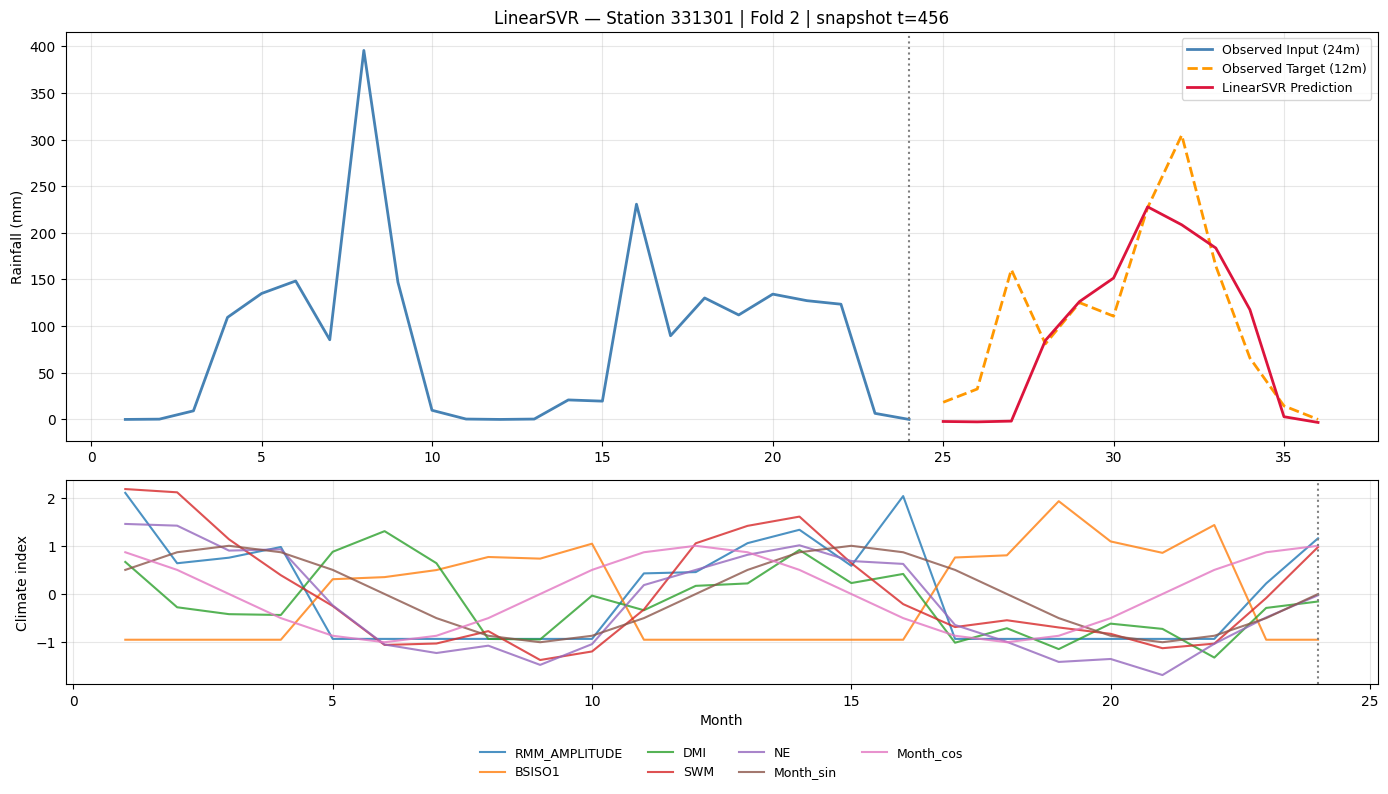

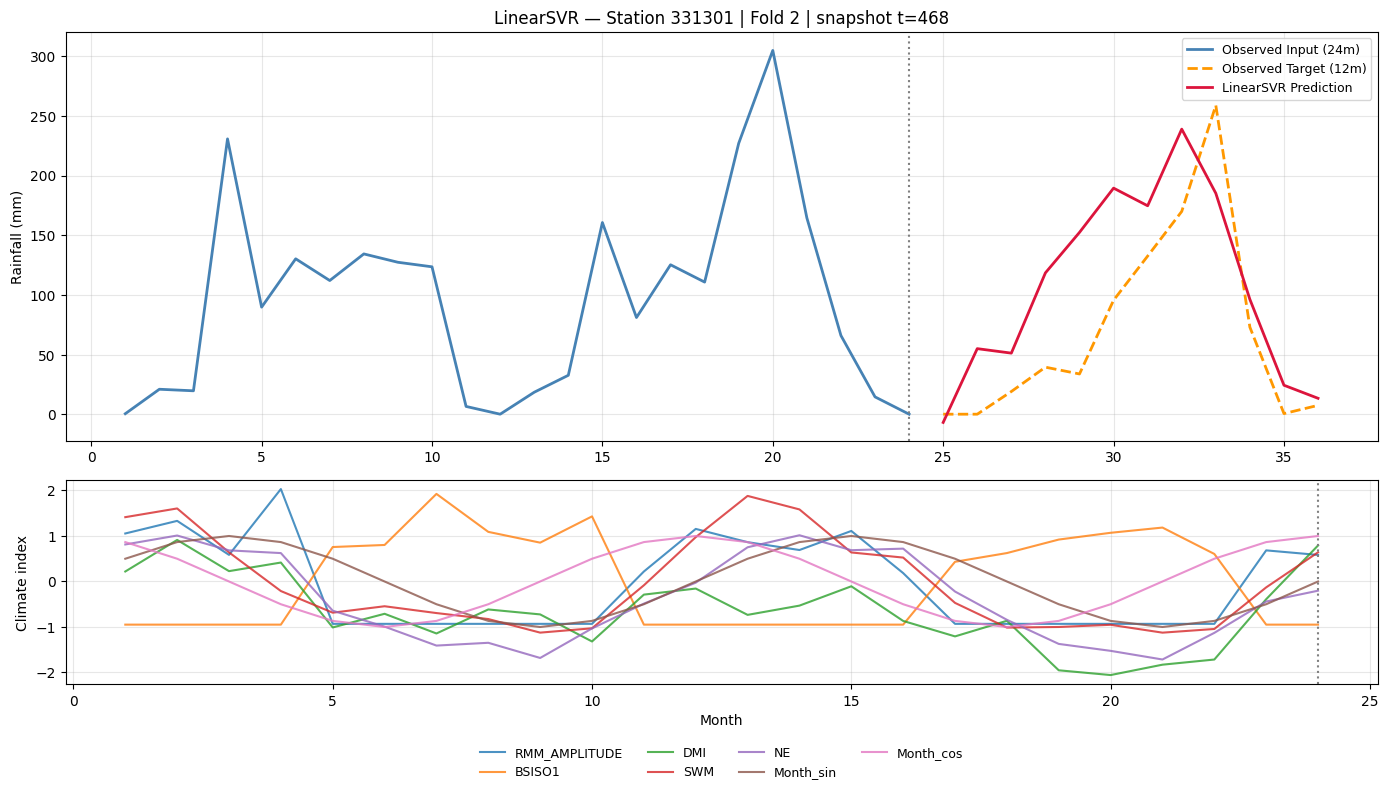

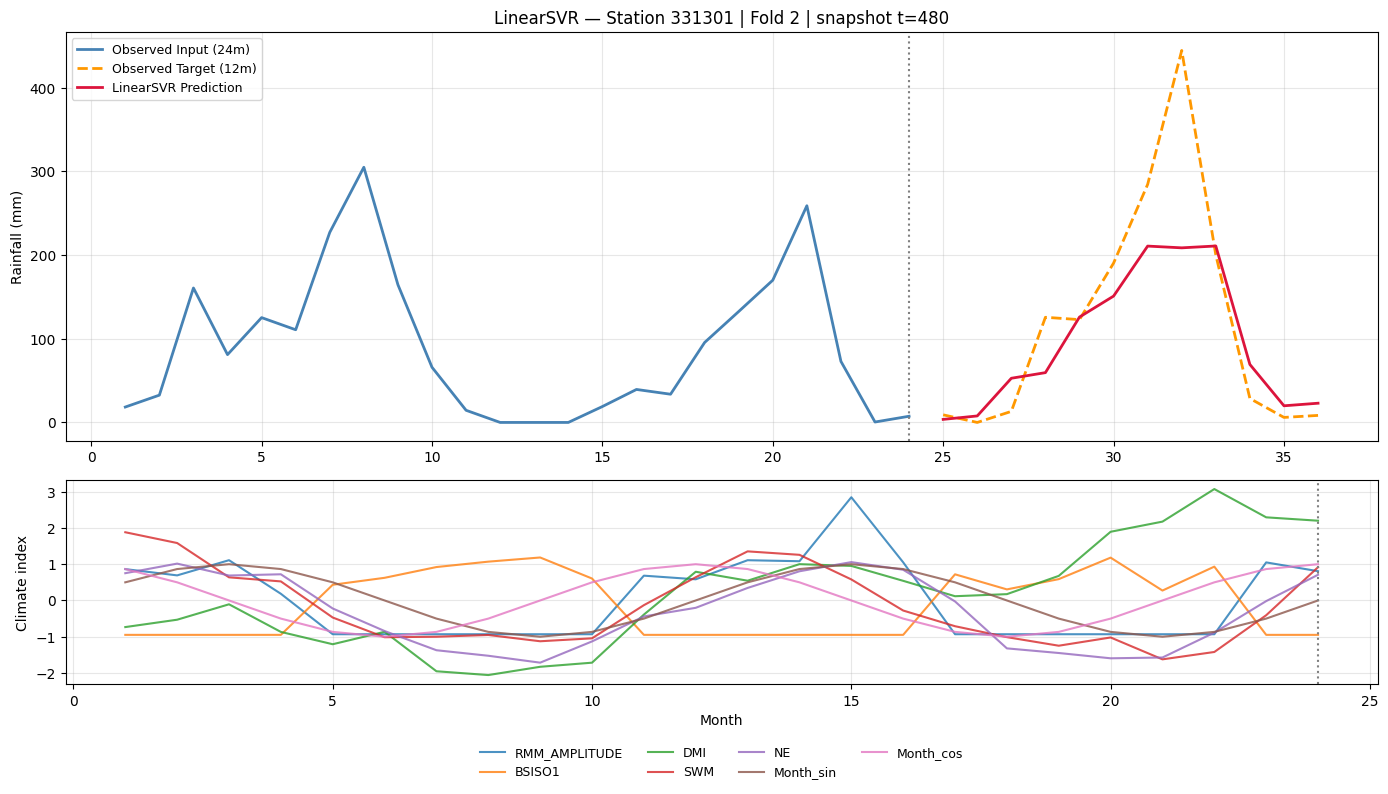

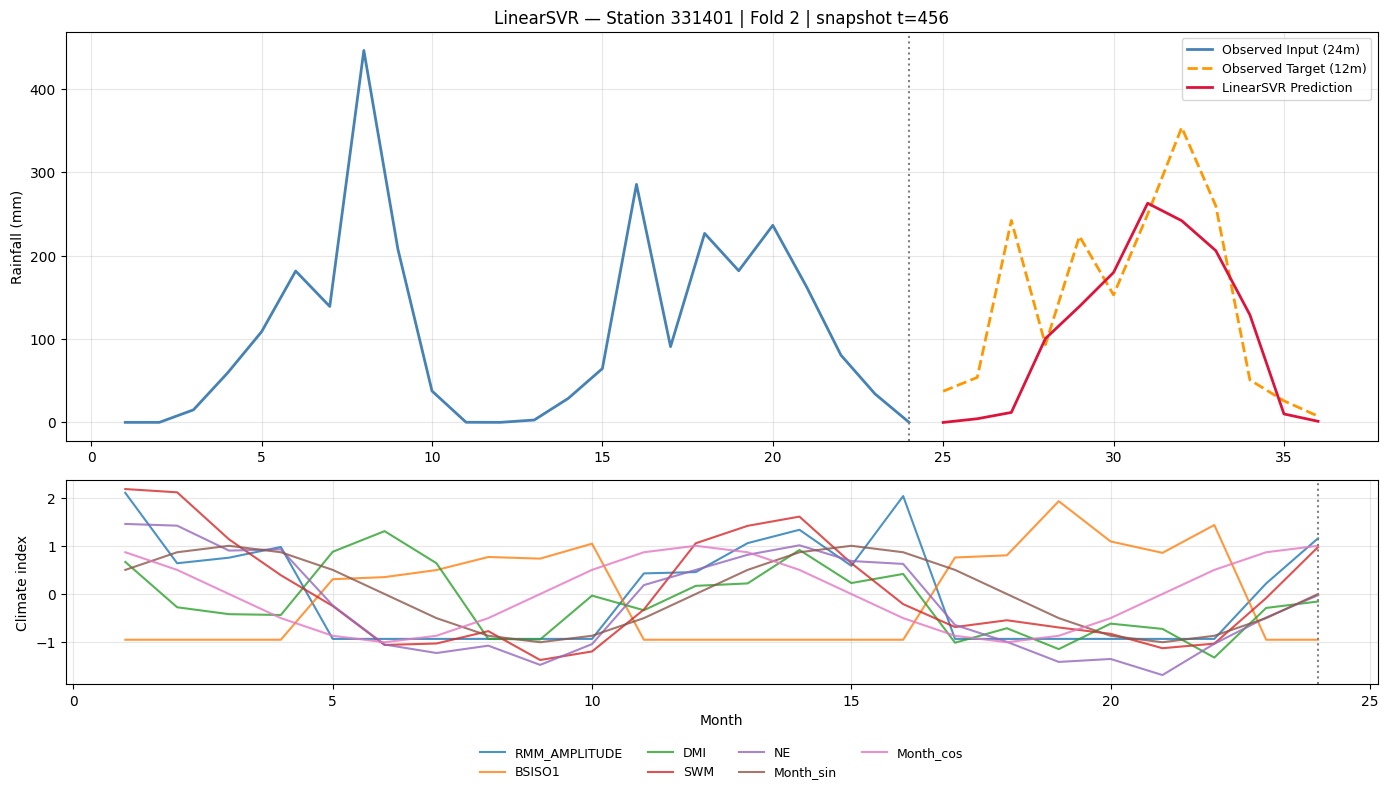

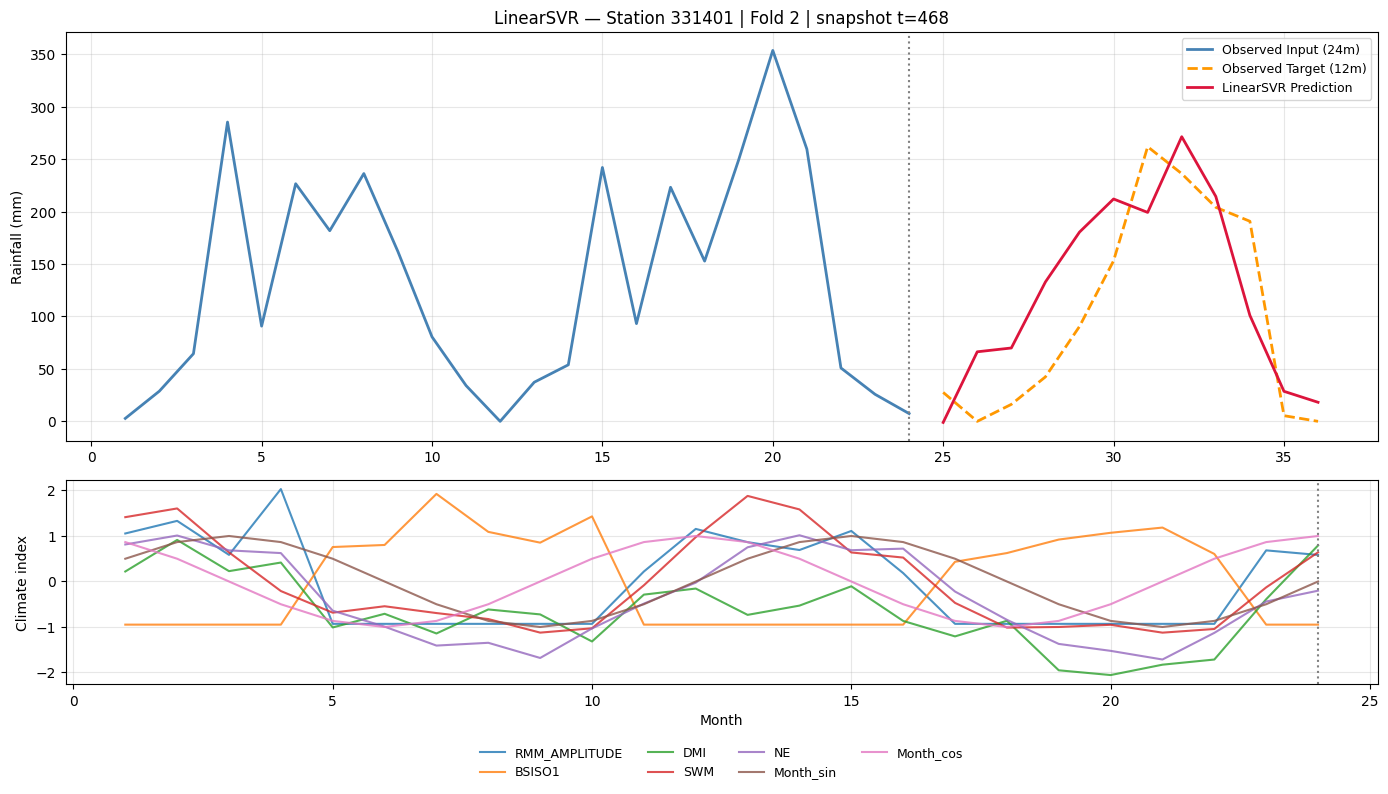

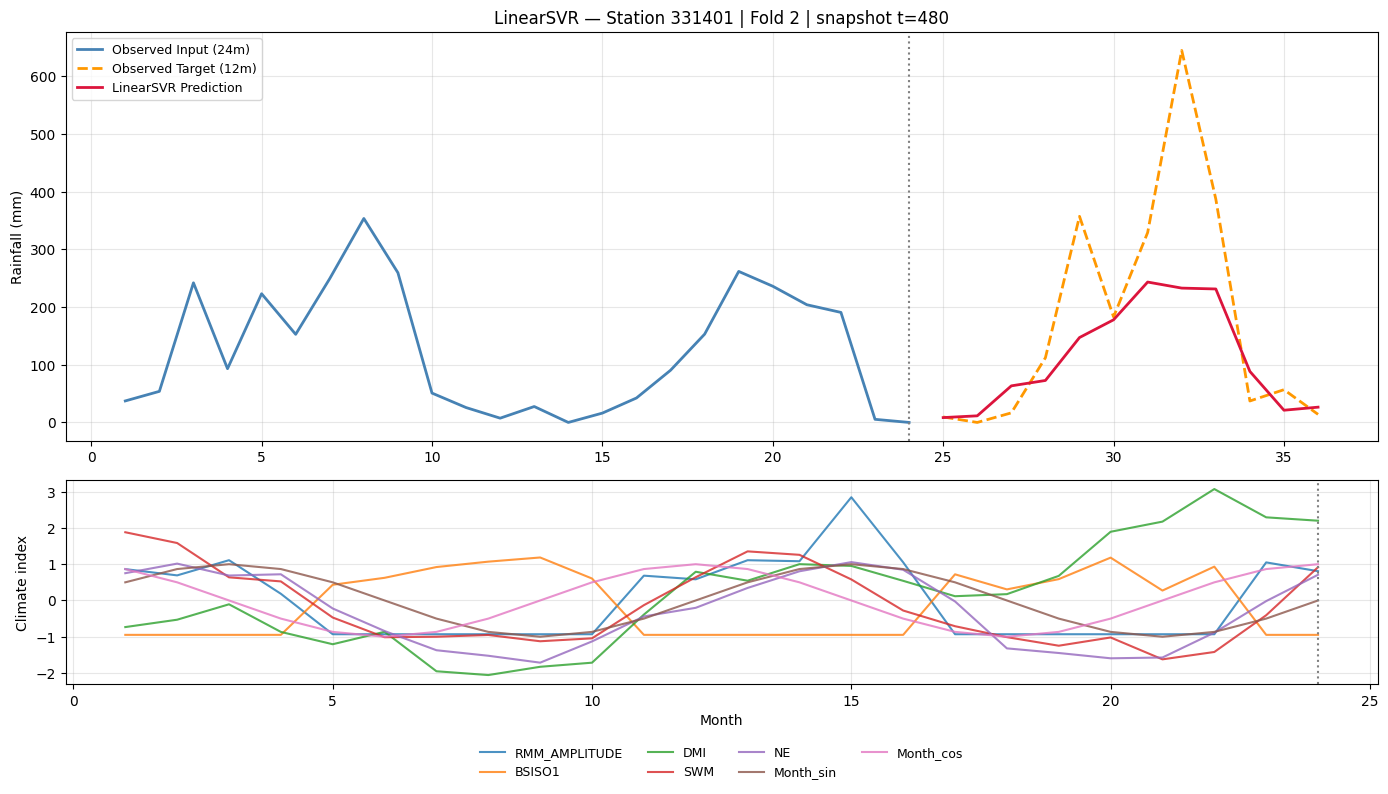

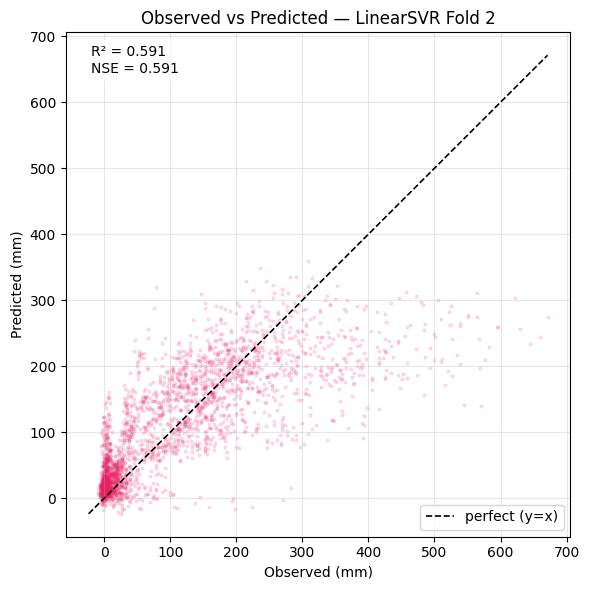


All LinearSVR plots saved to: /content/drive/MyDrive/Data_Minning/svr_results/


In [66]:
# ════════════════════════════════════════════════════════════════
# 6. กราฟ 1 — Time-series (3 กราฟต่อสถานี: ต้น กลาง ท้าย)
# ════════════════════════════════════════════════════════════════
top_n = 20
n_st = len(cluster_station)

fold_index = 1  # 0 = Fold 1, 1 = Fold 2
if True:
    r              = all_svr_results[fold_index] # Changed to SVR results
    fold_label_num = r['fold_label_num']
    train_list     = r['train_list']
    test_list      = r['test_list']
    model          = r['model']
    fold_label     = '2019–2021' if fold_index == 0 else '2022–2024'

    for st_idx in range(n_st):
        scaler_col = cluster_station[st_idx]
        st_name    = node['Node'].iloc[cluster_station[st_idx]]

        df_tr   = train_list[cluster_station[st_idx]]
        df_te   = test_list [cluster_station[st_idx]]
        df_full = pd.concat([df_tr, df_te])
        df_full = df_full[~df_full.index.duplicated(keep='last')].sort_index()

        test_start = df_te.index[0]
        full_idx   = df_full.index.tolist()
        try:
            start_j = full_idx.index(test_start) - window_size
        except ValueError:
            continue
        if start_j < 0: start_j = 0

        n_snap = len(df_te) - horizon + 1
        if n_snap <= 0: n_snap = 1
        snap_indices = [0, n_snap // 2, n_snap - 1]

        for snap in snap_indices:
            abs_j = start_j + snap
            window_sc = df_full.iloc[abs_j : abs_j + window_size].values
            target_sc = df_full.iloc[abs_j + window_size : abs_j + window_size + horizon, -1].values

            if len(window_sc) < window_size or len(target_sc) < horizon:
                continue

            base_m     = df_full.index[abs_j + window_size].month
            tgt_months = [(base_m - 1 + h) % 12 + 1 for h in range(horizon)]
            feat       = _make_features(window_sc, tgt_months, num_feature, climate_names_list)

            # Predict using LinearSVR models
            pred_sc = np.array([
                model.models[h].predict(feat.reshape(1, -1))[0]
                for h in range(horizon)
            ])

            rain_input_mm = inv_transform(window_sc[:, -1], scaler_col)
            target_mm     = inv_transform(target_sc,        scaler_col)
            pred_mm       = inv_transform(pred_sc,          scaler_col)

            t_input       = np.arange(1, window_size + 1)
            t_target      = np.arange(window_size + 1, window_size + horizon + 1)
            climate_input = window_sc[:, :num_feature]

            fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

            axes[0].plot(t_input, rain_input_mm, label=f'Observed Input ({window_size}m)', linewidth=2, color='steelblue')
            axes[0].plot(t_target, target_mm, label=f'Observed Target ({horizon}m)', linewidth=2, linestyle='--', color='#FF9800')
            axes[0].plot(t_target, pred_mm, label='LinearSVR Prediction', linewidth=2, color='crimson') # Changed label/color
            axes[0].axvline(window_size, color='gray', linestyle=':')
            axes[0].set_ylabel('Rainfall (mm)')
            axes[0].set_title(f'LinearSVR — Station {st_name} | Fold {fold_label_num} | snapshot t={abs_j}')
            axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

            for i, cname in enumerate(climate_name_list):
                axes[1].plot(t_input, climate_input[:, i], linewidth=1.5, alpha=0.8, label=cname)
            axes[1].axvline(window_size, color='gray', linestyle=':')
            axes[1].set_ylabel('Climate index'); axes[1].set_xlabel('Month')
            axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=min(4, len(climate_name_list)), fontsize=9, frameon=False)
            axes[1].grid(alpha=0.3)


            plt.tight_layout()
            save_path = os.path.join(SVR_SAVE_DIR, f'plot_ts_fold{fold_label_num}_st{st_name}_snap{abs_j}.png')
            plt.savefig(save_path, dpi=120, bbox_inches='tight')
            plt.show(); plt.close()


# ════════════════════════════════════════════════════════════════
# 7. กราฟ 2 — Scatter: Observed vs Predicted
# ════════════════════════════════════════════════════════════════

fold_index = 1  # 0 = Fold 1, 1 = Fold 2
if True:
    r              = all_svr_results[fold_index]
    fold_label_num = r['fold_label_num']
    Y_te           = r['Y_te']
    Y_pred         = r['Y_pred_te']
    n_steps_sc     = Y_te.shape[0] // n_st

    Y_te_rs   = Y_te  [:n_steps_sc*n_st].reshape(n_steps_sc, n_st, horizon)
    Y_pred_rs = Y_pred[:n_steps_sc*n_st].reshape(n_steps_sc, n_st, horizon)

    obs_all, pred_all = [], []
    for st_idx in range(n_st):
        scaler_col = cluster_station[st_idx]
        for h in range(horizon):
            obs_all.append(inv_transform(Y_te_rs  [:, st_idx, h], scaler_col))
            pred_all.append(inv_transform(Y_pred_rs[:, st_idx, h], scaler_col))
    yt, yp = np.concatenate(obs_all), np.concatenate(pred_all)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(yt, yp, alpha=0.12, s=4, color='#E91E63') # Changed color to indicate SVR
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='perfect (y=x)')
    ax.set_xlabel('Observed (mm)'); ax.set_ylabel('Predicted (mm)')
    ax.set_title(f'Observed vs Predicted — LinearSVR Fold {fold_label_num}')
    ax.text(0.05, 0.92, f'R² = {r2_score(yt, yp):.3f}\nNSE = {_nse(yt, yp):.3f}',
            transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(SVR_SAVE_DIR, f'plot_scatter_fold{fold_label_num}.png')
    plt.savefig(save_path, dpi=150)
    plt.show()


print("\nAll LinearSVR plots saved to:", SVR_SAVE_DIR)

In [60]:
df_full.index[abs_j + window_size]  # เดือนแรกที่ทำนาย

Timestamp('2024-01-01 00:00:00')


Computing importance for LinearSVR (Fold 1)
Detected 264 features in X_te...


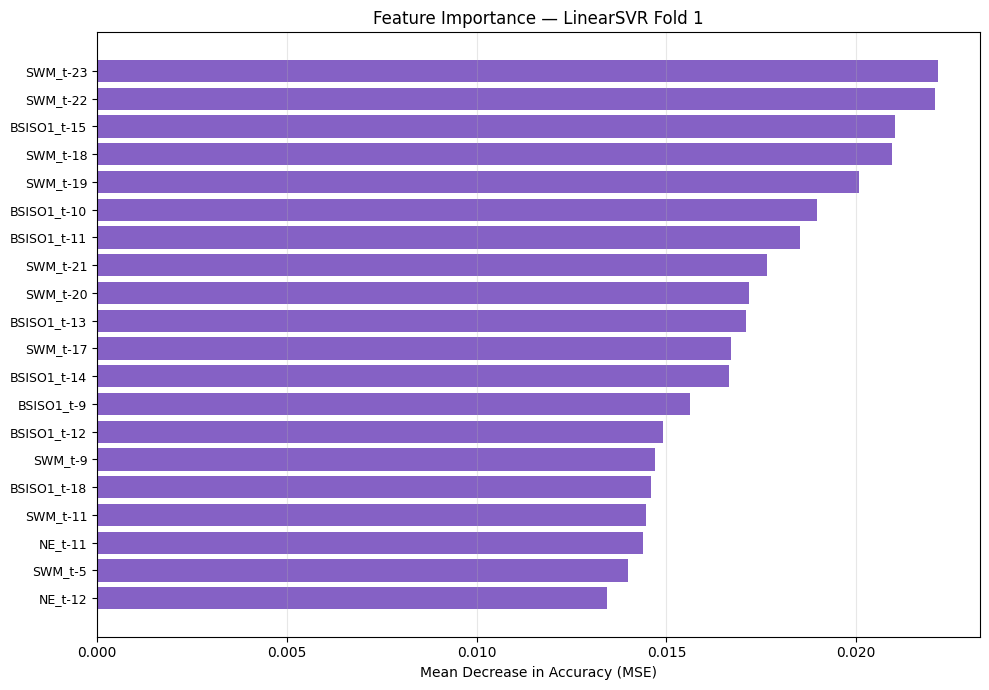


Computing importance for LinearSVR (Fold 2)
Detected 264 features in X_te...


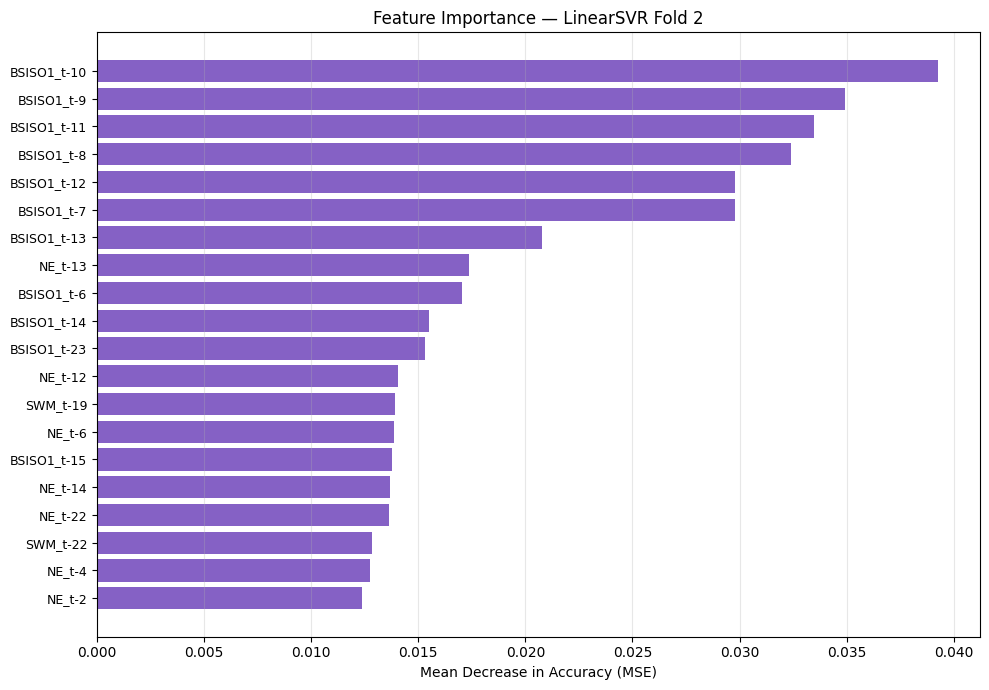

Plots saved to /content/drive/MyDrive/Data_Minning/svr_results/


In [61]:
# ════════════════════════════════════════════════════════════════
# 8. กราฟ 3 — Feature Importance (Permutation) - ROBUST FIX
# ════════════════════════════════════════════════════════════════

top_n = 20

for fold_index in range(k_fold_num):
    r = all_svr_results[fold_index]
    fold_label_num = r['fold_label_num']
    X_sub, Y_sub = r['X_te'][:200], r['Y_te'][:200]

    num_total_features = X_sub.shape[1]
    print(f"\nComputing importance for LinearSVR (Fold {fold_label_num})")
    print(f"Detected {num_total_features} features in X_te...")

    # --- 1. Dynamic Feature Name Reconstruction ---
    feat_names = []

    # Part A: Window Features
    # Your _make_features uses window.flatten(), which is (window_size * num_cols)
    # num_cols = n_climate + 1 (for rainfall)
    num_cols = num_feature + 1
    for i in range(window_size):
        for cname in list(climate_name_list) + ['rain']:
            feat_names.append(f"{cname}_t-{window_size-i}")

    # Part B: Climate Stats
    for cname in climate_name_list:
        for stat in ['mean', 'std', 'trend', 'mean3m', 'mean6m', 'p90']:
            feat_names.append(f"{cname}_{stat}")

    # Part C: Rain Lags
    for lag in range(1, 7):
        feat_names.append(f"rain_lag{lag}")

    # Part D: Cyclic Months
    for h in range(1, horizon + 1):
        feat_names.append(f"sin_h{h}")
        feat_names.append(f"cos_h{h}")

    # --- 2. Safety Check for Indexing ---
    # If there's still a mismatch, fill the rest with generic names
    while len(feat_names) < num_total_features:
        feat_names.append(f"extra_feat_{len(feat_names)}")

    # --- 3. Compute Importance ---
    imp_all = np.zeros(num_total_features)
    for h in range(horizon):
        result = permutation_importance(
            r['model'].models[h], X_sub, Y_sub[:, h],
            n_repeats=5, random_state=42, scoring='neg_mean_squared_error'
        )
        imp_all += result.importances_mean
    imp_all /= horizon

    # --- 4. Plotting ---
    top_idx = np.argsort(imp_all)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_vals = imp_all[top_idx][::-1]
    # Use index-based selection to prevent IndexError
    plot_names = [feat_names[i] for i in top_idx[::-1]]

    ax.barh(range(len(plot_vals)), plot_vals, color='#673AB7', alpha=0.8)
    ax.set_yticks(range(len(plot_vals)))
    ax.set_yticklabels(plot_names, fontsize=9)
    ax.set_title(f'Feature Importance — LinearSVR Fold {fold_label_num}')
    ax.set_xlabel('Mean Decrease in Accuracy (MSE)')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(SVR_SAVE_DIR, f'plot_importance_fold{fold_label_num}.png')
    plt.savefig(save_path, dpi=150)
    plt.show()

print(f"Plots saved to {SVR_SAVE_DIR}")